# GTSRB Traffic Sign Classification — ViT Fine-Tuning (RunPod, single GPU)

**v2 — reworked to fix the dataset problem.**

### Why this version exists

The Hugging Face copy of GTSRB (`bazyl/GTSRB`) stores images in parquet and
**throws away the original filenames**. That matters more than it sounds:
GTSRB encodes its *track* structure in the filename (`00000_00029.ppm` =
track 00000, frame 29). Each track is ~30 near-duplicate video frames of the
*same physical sign*. Without filenames, tracks can't be recovered — and
without tracks, a train/val split leaks near-duplicates across the split and
inflates validation accuracy. (That leak is exactly why the first run showed
88% val but only 71% on the official test set.)

So this notebook downloads the **original GTSRB archives** from the official
mirror, which keep the filenames — and therefore the tracks — intact.

### What changed vs. the first version

| Area | v1 | v2 |
|---|---|---|
| Data source | Kaggle (auth broke) / HF (filenames lost) | Official mirror, filenames intact |
| Track IDs | unrecoverable | parsed from real filenames |
| Val split | random (leaky) | **stratified track-aware** — every class in both splits, zero track leakage |
| Format | expects PNG | converts PPM → PNG once, in parallel |
| Pipeline | re-decodes every epoch | decode once + `cache()` |
| Unfreezing | guessed at layer names | robust block finder + verification |
| Results | saved to pod only | zipped for download |

### Run order
Top to bottom. Sections 3–4 are one-time (dataset prep); once done they're
skipped automatically on re-runs.


## 1. Environment check

In [1]:
pip install --upgrade keras keras-hub "tensorflow[and-cuda]" pandas scikit-learn seaborn matplotlib --break-system-packages

  Using cached tensorflow-2.21.0-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached h5py-3.14.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)
INFO: pip is looking at multiple versions of tensorflow-text to determine which version is compatible with other requirements. This could take a while.
  Using cached tensorflow_text-2.20.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached tensorflow_text-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.0 kB)
  Using cached tensorflow_text-2.18.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached tensorflow_text-2.18.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached tensorflow_text-2.17.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached tensorflow_text-2.16.1-cp311-cp311-manylinux_2_17_x86_64.manylinu

In [2]:
!nvidia-smi


Fri Jul 24 00:40:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:E1:00.0 Off |                  N/A |
| 30%   29C    P8             30W /  350W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### GPU smoke test — run this FIRST, before anything else

TensorFlow **does not work on Blackwell GPUs** (compute capability 12.0):
RTX 5090, RTX PRO 4000/4500/5000/6000 Blackwell, B200. The TF wheels ship no
sm_120 kernels, fall back to JIT-compiling from PTX, and that PTX is too old to
target Blackwell — so every GPU op dies with `CUDA_ERROR_INVALID_PTX`. This is
an open TensorFlow bug across 2.18–2.21, not something you can fix with a pip
install.

**Use an Ada or Ampere GPU instead:** RTX 4090, RTX 4000 Ada, L40S, L40, L4,
A100, A6000, A5000, A40, RTX 3090.

The cell below does a real GPU computation and fails immediately if the card is
unusable — costing you seconds instead of a dataset prep plus a training run.


In [13]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible:", gpus)
assert gpus, "No GPU detected — check the pod actually has a GPU attached."

# Report compute capability and warn on known-unsupported architectures.
details = tf.config.experimental.get_device_details(gpus[0])
cc = details.get("compute_capability")
print("Device name        :", details.get("device_name"))
print("Compute capability :", cc)

if cc is not None and cc[0] >= 12:
    print("\n*** WARNING: Blackwell-class GPU (sm_120). TensorFlow does not "
          "support this. Expect CUDA_ERROR_INVALID_PTX. Switch to an Ada or "
          "Ampere GPU (RTX 4090, L40S, A6000, A5000, A100, L4, 3090). ***")

# Actual GPU computation — this is what catches a broken architecture.
try:
    with tf.device("/GPU:0"):
        a = tf.random.normal((512, 512))
        b = tf.random.normal((512, 512))
        c = tf.matmul(a, b)
        result = float(tf.reduce_sum(c).numpy())
    print(f"\nGPU smoke test PASSED (checksum {result:.2f}) — safe to continue.")
except Exception as e:
    raise RuntimeError(
        "GPU smoke test FAILED — this GPU cannot run TensorFlow.\n"
        "If you see CUDA_ERROR_INVALID_PTX, the card is Blackwell (sm_120) and "
        "TensorFlow has no working kernels for it. Stop here, terminate this "
        "pod, and redeploy on an Ada/Ampere GPU (RTX 4090, L40S, A6000, A5000, "
        "A100, L4, 3090). Do not spend time trying to fix the CUDA install.\n\n"
        f"Original error: {e}"
    ) from e

# Single GPU on purpose: no MirroredStrategy. The dual-T4 setup caused the
# per-replica vs global batch size confusion and the optimizer-variable
# mismatch warnings on reload in the original notebook.


TensorFlow: 2.20.0
Keras: 3.15.0
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device name        : NVIDIA GeForce RTX 3090
Compute capability : (8, 6)

GPU smoke test PASSED (checksum 1469.62) — safe to continue.


## 2. Paths & hyperparameters

In [4]:
DATASET_PATH = "/workspace/data/gtsrb"          # where the prepared dataset will live
RAW_DIR = "/workspace/data/gtsrb_raw"           # where the official zips are downloaded/extracted

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
TEST_DIR = os.path.join(DATASET_PATH, "Test")
TEST_CSV_PATH = os.path.join(DATASET_PATH, "Test.csv")

OUTPUT_DIR = "/workspace/outputs/gtsrb_vit"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Hyperparameters -------------------------------------------------------
NUM_CLASSES = 43
IMAGE_SIZE = 224            # required by the pretrained ViT preset
BATCH_SIZE = 64             # Reduced from 128: full 12-block fine-tuning needs far more
                            # activation memory than the 4-block version. Raise back toward
                            # 128 only if nvidia-smi shows plenty of headroom.

VAL_FRACTION = 0.2

# Phase 1: classifier head only (backbone frozen)
HEAD_EPOCHS = 8
HEAD_LR = 1e-3

# Phase 2: unfreeze the last N transformer blocks, fine-tune end-to-end
# ---------------------------------------------------------------------------
# CORRECTED BASELINE (v3). The v2 run reached only 91% test / 83% val, well
# short of the 97-99% that fine-tuned ViT-Base is normally reported to reach on
# GTSRB. Phase 2 ended at 98.9% train vs 82.8% val -- fitting the training
# tracks hard while failing to generalise. Three changes address that:
#   1. Unfreeze all 12 blocks, not 4. Adapting only the top third of the
#      network leaves most of the ImageNet representation unadapted to a domain
#      (small, low-res, high-contrast pictograms) that is far from ImageNet.
#   2. Warmup + cosine decay instead of a flat LR. Standard practice for ViT
#      fine-tuning; the warmup matters most in the first few hundred steps,
#      when newly-unfrozen blocks would otherwise take large destructive steps.
#   3. Higher base LR (5e-5), which the schedule makes safe.
# These are starting points, not tuned optima -- expect to adjust.
FINE_TUNE_EPOCHS = 15
FINE_TUNE_LR = 5e-5           # peak LR after warmup (was flat 1e-5)
UNFREEZE_LAST_N_BLOCKS = 12   # ViT-Base has 12 blocks -> full fine-tune
FREEZE_EMBEDDINGS = False     # v2 froze these; full fine-tuning normally doesn't
WARMUP_EPOCHS = 1             # linear ramp 0 -> FINE_TUNE_LR, then cosine decay

# ---- Experiment flags ------------------------------------------------------
# Both v2 interventions are now switchable so they can be ablated one at a
# time. They were applied *together* in v2, which is why their individual
# contributions to the 91% -> 82% regression can't be separated from that run.
#
# 'balanced' class weighting is OFF by default: it gave rare classes ~4.05x
# weight and common ones ~0.3x, which pushed the model to over-predict
# minority classes (class 19 predicted 2.7x more often than it occurs) and
# cost ~8.6 points of accuracy -- while making class 37, its actual target,
# worse (8.3% -> 3.3% recall).
USE_CLASS_WEIGHTS = False
# Contrast stretch OFF by default too, so the corrected baseline is a clean
# ViT fine-tune with no preprocessing intervention. Turn back on to ablate.
USE_CONTRAST_STRETCH = False

# Mixed precision roughly halves memory and can ~2x throughput on Ada GPUs.
# Left OFF by default because it can occasionally cause loss-scaling issues
# with from_logits losses, and a failed run costs more than a slower one.
# Once you have one clean successful run, try flipping this to True.
USE_MIXED_PRECISION = False

SEED = 123

if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", keras.mixed_precision.global_policy().name)


## 3. Download the official GTSRB archives (one-time)

Source: the official mirror hosted by the University of Copenhagen (this is the
same archive `torchvision.datasets.GTSRB` downloads from). No login, no API
token, no Kaggle account needed.

Three archives:
- `GTSRB_Final_Training_Images.zip` (~263 MB) — training images, **filenames intact**
- `GTSRB_Final_Test_Images.zip` (~84 MB) — official test images
- `GTSRB_Final_Test_GT.zip` (~98 KB) — official test ground-truth labels


In [19]:
!apt-get update -qq && apt-get install -y -qq unzip wget


In [20]:
BASE_URL = "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370"
ARCHIVES = [
    "GTSRB_Final_Training_Images.zip",
    "GTSRB_Final_Test_Images.zip",
    "GTSRB_Final_Test_GT.zip",
]

os.makedirs(RAW_DIR, exist_ok=True)

for name in ARCHIVES:
    dest = os.path.join(RAW_DIR, name)
    if os.path.exists(dest):
        print(f"Already downloaded: {name}")
        continue
    print(f"Downloading {name} ...")
    # -c resumes if interrupted, so a dropped connection doesn't restart the download
    !wget -c -q --show-progress -O {dest} {BASE_URL}/{name}

print()
!ls -lh {RAW_DIR}


Already downloaded: GTSRB_Final_Training_Images.zip
Already downloaded: GTSRB_Final_Test_Images.zip
Already downloaded: GTSRB_Final_Test_GT.zip

total 351M
-rw-rw-rw- 1 root root 369K Jan 18  2011 GT-final_test.csv
drwxrwxrwx 4 root root 2.0M Jul 15 01:33 GTSRB
-rw-rw-rw- 1 root root  98K May 10  2019 GTSRB_Final_Test_GT.zip
-rw-rw-rw- 1 root root  85M May 10  2019 GTSRB_Final_Test_Images.zip
-rw-rw-rw- 1 root root 264M May 10  2019 GTSRB_Final_Training_Images.zip


In [21]:
# Extract. Skipped automatically if already extracted.
train_marker = os.path.join(RAW_DIR, "GTSRB", "Final_Training", "Images")
test_marker = os.path.join(RAW_DIR, "GTSRB", "Final_Test", "Images")

if not os.path.isdir(train_marker):
    print("Extracting training images...")
    !unzip -q -o {RAW_DIR}/GTSRB_Final_Training_Images.zip -d {RAW_DIR}
else:
    print("Training images already extracted.")

if not os.path.isdir(test_marker):
    print("Extracting test images...")
    !unzip -q -o {RAW_DIR}/GTSRB_Final_Test_Images.zip -d {RAW_DIR}
else:
    print("Test images already extracted.")

print("Extracting test ground truth...")
!unzip -q -o {RAW_DIR}/GTSRB_Final_Test_GT.zip -d {RAW_DIR}

print()
print("Train images dir exists:", os.path.isdir(train_marker))
print("Test images dir exists: ", os.path.isdir(test_marker))
print()
print("Sample training filenames (note the track_frame structure):")
sample_class = sorted(os.listdir(train_marker))[0]
print(" ", sample_class, "->", sorted(os.listdir(os.path.join(train_marker, sample_class)))[:4])


Training images already extracted.
Test images already extracted.
Extracting test ground truth...

Train images dir exists: True
Test images dir exists:  True

Sample training filenames (note the track_frame structure):
  00000 -> ['00000_00000.ppm', '00000_00001.ppm', '00000_00002.ppm', '00000_00003.ppm']


## 4. Convert PPM → PNG (one-time)

The official archives ship `.ppm` images, which TensorFlow can't decode
natively. We convert once to PNG on disk (rather than decoding PPM through a
slow `tf.py_function` on every epoch), **preserving the original filenames** so
the track IDs survive.

This runs in parallel across all vCPUs. Output layout mirrors the familiar
Kaggle structure, so the rest of the notebook is source-agnostic:

```
/workspace/data/gtsrb/
  Train/00000/00000_00000.png ...
  Test/00000.png ...
  Test.csv                       # columns: Path, ClassId
```


In [22]:
import glob
import shutil
from multiprocessing import Pool, cpu_count
from PIL import Image
import pandas as pd
from tqdm import tqdm

RAW_TRAIN = os.path.join(RAW_DIR, "GTSRB", "Final_Training", "Images")
RAW_TEST = os.path.join(RAW_DIR, "GTSRB", "Final_Test", "Images")

def _convert(job):
    src, dst = job
    if os.path.exists(dst):
        return
    Image.open(src).convert("RGB").save(dst, "PNG")

def convert_all(jobs, desc):
    if not jobs:
        print(f"{desc}: nothing to do (already converted).")
        return
    with Pool(processes=cpu_count()) as pool:
        list(tqdm(pool.imap_unordered(_convert, jobs, chunksize=200),
                  total=len(jobs), desc=desc))

# ---- Training images -------------------------------------------------------
train_jobs = []
for class_dir in sorted(os.listdir(RAW_TRAIN)):
    src_class_path = os.path.join(RAW_TRAIN, class_dir)
    if not os.path.isdir(src_class_path):
        continue
    dst_class_path = os.path.join(TRAIN_DIR, class_dir)
    os.makedirs(dst_class_path, exist_ok=True)
    for fname in os.listdir(src_class_path):
        if not fname.lower().endswith(".ppm"):
            continue
        dst_name = os.path.splitext(fname)[0] + ".png"   # keeps 00000_00029 stem
        train_jobs.append((os.path.join(src_class_path, fname),
                           os.path.join(dst_class_path, dst_name)))

convert_all(train_jobs, "Train PPM->PNG")

# ---- Test images -----------------------------------------------------------
os.makedirs(TEST_DIR, exist_ok=True)
test_jobs = []
for fname in os.listdir(RAW_TEST):
    if not fname.lower().endswith(".ppm"):
        continue
    dst_name = os.path.splitext(fname)[0] + ".png"
    test_jobs.append((os.path.join(RAW_TEST, fname),
                      os.path.join(TEST_DIR, dst_name)))

convert_all(test_jobs, "Test PPM->PNG")

n_train = sum(len(files) for _, _, files in os.walk(TRAIN_DIR))
n_test = len([f for f in os.listdir(TEST_DIR) if f.endswith(".png")])
print(f"\nTrain images: {n_train}   (expected 39209)")
print(f"Test images:  {n_test}   (expected 12630)")


Test PPM->PNG: 100%|██████████| 12630/12630 [00:00<00:00, 27833.06it/s]



Train images: 39209   (expected 39209)
Test images:  12630   (expected 12630)


In [23]:
# ---- Build Test.csv from the official ground truth --------------------------
# GT-final_test.csv is semicolon-separated with columns:
# Filename;Width;Height;Roi.X1;Roi.Y1;Roi.X2;Roi.Y2;ClassId
gt_candidates = glob.glob(os.path.join(RAW_DIR, "**", "GT-final_test.csv"), recursive=True)
assert gt_candidates, "GT-final_test.csv not found — check the GT zip extracted correctly."
gt_path = gt_candidates[0]
print("Using ground truth:", gt_path)

gt = pd.read_csv(gt_path, sep=";")
print("Ground truth columns:", list(gt.columns))

test_df_out = pd.DataFrame({
    "Path": ["Test/" + os.path.splitext(f)[0] + ".png" for f in gt["Filename"]],
    "ClassId": gt["ClassId"].astype(int),
})
test_df_out.to_csv(TEST_CSV_PATH, index=False)

print(f"\nWrote {TEST_CSV_PATH}  ({len(test_df_out)} rows)")
print(test_df_out.head())

# Sanity: every referenced file must actually exist
missing = [p for p in test_df_out["Path"].head(50)
           if not os.path.exists(os.path.join(DATASET_PATH, p))]
assert not missing, f"Missing test images, e.g. {missing[:3]}"
print("\nSpot-check passed: test image paths resolve correctly.")


Using ground truth: /workspace/data/gtsrb_raw/GT-final_test.csv
Ground truth columns: ['Filename', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId']

Wrote /workspace/data/gtsrb/Test.csv  (12630 rows)
             Path  ClassId
0  Test/00000.png       16
1  Test/00001.png        1
2  Test/00002.png       38
3  Test/00003.png       33
4  Test/00004.png       11

Spot-check passed: test image paths resolve correctly.


## 5. Stratified track-aware train/validation split

Filenames look like `00000_00029.png` inside class folder `00000`:
`{track}_{frame}`. All frames sharing a track are the *same physical sign*, so
they must never straddle the split.

We hold out `VAL_FRACTION` of **tracks within each class** (stratified), which:
- guarantees zero track leakage between train and val,
- guarantees all 43 classes appear in *both* splits (a plain global track
  shuffle drops rare classes out of val entirely),
- makes validation accuracy a genuine predictor of official test accuracy.


In [24]:
import re
import numpy as np

def list_gtsrb_train_files(train_dir):
    """DataFrame of (filepath, class_id, track_id) for every training image."""
    rows = []
    for class_dir in sorted(os.listdir(train_dir)):
        class_path = os.path.join(train_dir, class_dir)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(".png"):
                continue
            m = re.match(r"(\d+)_(\d+)", fname)
            if m is None:
                raise ValueError(
                    f"Filename '{fname}' has no track structure. The track-aware "
                    "split needs original GTSRB filenames — re-check Section 4."
                )
            rows.append({
                "filepath": os.path.join(class_path, fname),
                "class_id": int(class_dir),
                "track_id": f"{class_dir}_{m.group(1)}",
            })
    return pd.DataFrame(rows)

file_df = list_gtsrb_train_files(TRAIN_DIR)
print(f"Training images : {len(file_df)}")
print(f"Unique tracks   : {file_df['track_id'].nunique()}")
print(f"Classes         : {file_df['class_id'].nunique()}")
print(f"Mean frames/track: {len(file_df) / file_df['track_id'].nunique():.1f}")


Training images : 39209
Unique tracks   : 1307
Classes         : 43
Mean frames/track: 30.0


In [25]:
def stratified_track_split(df, val_frac, seed):
    """Hold out val_frac of tracks *within each class*."""
    rng = np.random.RandomState(seed)
    val_tracks = set()
    for class_id, grp in df.groupby("class_id"):
        tracks = np.array(sorted(grp["track_id"].unique()))
        tracks = tracks[rng.permutation(len(tracks))]
        k = max(1, int(round(len(tracks) * val_frac)))
        k = min(k, len(tracks) - 1)          # never take every track of a class
        val_tracks.update(tracks[:k])
    return val_tracks

val_tracks = stratified_track_split(file_df, VAL_FRACTION, SEED)
file_df["is_val"] = file_df["track_id"].isin(val_tracks)

train_df = file_df[~file_df["is_val"]].reset_index(drop=True)
val_df = file_df[file_df["is_val"]].reset_index(drop=True)

print(f"Train: {len(train_df)} images / {train_df['track_id'].nunique()} tracks / "
      f"{train_df['class_id'].nunique()} classes")
print(f"Val  : {len(val_df)} images / {val_df['track_id'].nunique()} tracks / "
      f"{val_df['class_id'].nunique()} classes  ({100*len(val_df)/len(file_df):.1f}%)")

# ---- Hard guarantees: fail loudly rather than train on a broken split -------
leaked = set(train_df["track_id"]) & set(val_df["track_id"])
assert not leaked, f"Track leakage detected: {list(leaked)[:5]}"
assert train_df["class_id"].nunique() == NUM_CLASSES, "Some classes missing from train!"
assert val_df["class_id"].nunique() == NUM_CLASSES, "Some classes missing from val!"
print("\nChecks passed: no track leakage, all 43 classes present in both splits.")


Train: 31379 images / 1046 tracks / 43 classes
Val  : 7830 images / 261 tracks / 43 classes  (20.0%)

Checks passed: no track leakage, all 43 classes present in both splits.


## 5b. Class weights for imbalanced classes

GTSRB is heavily imbalanced (some classes have 1,500+ training images, others
well under 300). Section 12's classification report showed this isn't just a
mild effect -- **class 37 ("Go straight or left") sits at 8.3% recall**, an
order of magnitude below the model's overall 91.08% accuracy, and distinct
from the mirror-pair confusions Section 13 investigates.

Rather than hand-picking class 37 alone, this computes `sklearn`'s standard
`'balanced'` class weights from the **training split's actual class counts**
(post track-aware split, so it reflects what the model really sees). This
up-weights every under-represented class proportionally to its rarity --
class 37 should be one of the largest beneficiaries, which is checked below
rather than assumed.

Applied via `class_weight=` in both `model.fit()` calls in Sections 8 and 9.
This changes the *loss*, not the data, so Sections 6-7's pipeline are
untouched by this cell.

In [26]:
from sklearn.utils.class_weight import compute_class_weight

# Always computed (cheap, and the numbers are worth reporting either way);
# only *applied* in model.fit if USE_CLASS_WEIGHTS is True. See Section 2.
class_ids_present = np.array(sorted(train_df["class_id"].unique()))
_weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids_present,
    y=train_df["class_id"].values,
)
class_weights = {int(c): float(w) for c, w in zip(class_ids_present, _weights)}

_ranked = sorted(class_weights.items(), key=lambda kv: -kv[1])
print("5 most up-weighted classes (rarest in the training split):")
for class_id, w in _ranked[:5]:
    n = int((train_df["class_id"] == class_id).sum())
    print(f"  class {class_id:>2}: weight={w:.2f}  (n={n} training images)")
print(f"  ...")
for class_id, w in _ranked[-3:]:
    n = int((train_df["class_id"] == class_id).sum())
    print(f"  class {class_id:>2}: weight={w:.2f}  (n={n} training images)  <- most DOWN-weighted")

print(f"\nWeight ratio rarest:commonest = {_ranked[0][1] / _ranked[-1][1]:.1f}x")
_applied = "BE" if USE_CLASS_WEIGHTS else "NOT be"
print(f"\nUSE_CLASS_WEIGHTS = {USE_CLASS_WEIGHTS}  ->  weights will {_applied} passed to model.fit()")


5 most up-weighted classes (rarest in the training split):
  class  0: weight=4.05  (n=180 training images)
  class 19: weight=4.05  (n=180 training images)
  class 27: weight=4.05  (n=180 training images)
  class 32: weight=4.05  (n=180 training images)
  class 37: weight=4.05  (n=180 training images)
  ...
  class 13: weight=0.42  (n=1740 training images)  <- most DOWN-weighted
  class  1: weight=0.41  (n=1770 training images)  <- most DOWN-weighted
  class  2: weight=0.41  (n=1800 training images)  <- most DOWN-weighted

Weight ratio rarest:commonest = 10.0x

USE_CLASS_WEIGHTS = False  ->  weights will NOT be passed to model.fit()


## 6. Input pipeline

`decode → conditional contrast-stretch → cache → shuffle → resize → batch → augment → prefetch`

The `cache()` sits *after* decode but *before* resize on purpose. The raw GTSRB
images are tiny (15×15 to 250×250), so caching them costs ~100 MB of RAM and
means the 39k PNGs are decoded from disk **once** instead of every epoch.
Caching after the 224×224 resize would need ~23 GB, so we don't.

**New: deterministic contrast correction, folded into `decode_image`.**
Section 13c measured mean pixel brightness of ~60-131 for correctly-classified
images across the four mirror pairs, versus ~17-47 for misclassified ones.
Section 13d then showed that a percentile-based contrast stretch --
applied *only* at inference, and *only* to the 19/20 pair -- recovered 80%
of those misclassified images (12/15), while breaking 0/15 correct class-19
controls and 1/15 correct class-20 controls.

That's a validated fix, not a hypothesis, so it's applied here as a permanent,
**deterministic** (not random) step: any image whose mean brightness falls
below 55/255 gets the same percentile stretch, before caching, applied
identically to train, val, *and* test (both use `decode_image`, so there's no
train/test skew). The threshold sits safely below every pair's correctly-
classified mean brightness measured in 13c (all >=60), so well-exposed images
should pass through unchanged.

Note this is a distinct mechanism from Section 7's `RandomBrightness`/
`RandomContrast` augmentation below, which already existed in this pipeline at
training time (factor=0.2) and evidently wasn't sufficient on its own --
that's *random* per-epoch jitter, which doesn't guarantee the model, or the
evaluation set, ever sees the specific dark conditions that were actually
failing. This deterministic step guarantees it. The random augmentation is
left in place underneath for general robustness.

This does mean val/test numbers from this run aren't a like-for-like
comparison with the pre-fix run -- that's intentional, since the goal is to
fix the actual evaluation distribution, not just training exposure.


In [27]:
AUTOTUNE = tf.data.AUTOTUNE

BRIGHTNESS_THRESHOLD = 55.0   # see Section 6 markdown -- below every correct-class mean from 13c

def conditional_contrast_stretch(img, low_percentile=1.0, high_percentile=99.0):
    """Deterministic percentile-based contrast stretch (same transform validated
    in Section 13d), applied only to images whose mean brightness is below
    BRIGHTNESS_THRESHOLD. Well-exposed images pass through unchanged (tf.cond),
    since the reason for gating on brightness -- rather than stretching every
    image unconditionally -- is that 13d's control group showed contrast
    correction can *break* some already-correct, already-bright predictions
    (e.g. class 33: 3/15 controls broken). Gating keeps the fix scoped to the
    population it was actually shown to help.
    Input/output stay uint8 to keep the post-cache() pipeline's memory profile
    unchanged.
    """
    img_f = tf.cast(img, tf.float32)
    brightness = tf.reduce_mean(img_f)

    def stretch():
        flat = tf.reshape(img_f, [-1])
        n = tf.shape(flat)[0]
        sorted_flat = tf.sort(flat)
        lo_idx = tf.cast(tf.round(low_percentile / 100.0 * tf.cast(n - 1, tf.float32)), tf.int32)
        hi_idx = tf.cast(tf.round(high_percentile / 100.0 * tf.cast(n - 1, tf.float32)), tf.int32)
        lo = sorted_flat[lo_idx]
        hi = tf.maximum(sorted_flat[hi_idx], lo + 1.0)  # avoid divide-by-zero on flat images
        stretched = (img_f - lo) / (hi - lo) * 255.0
        return tf.cast(tf.clip_by_value(stretched, 0.0, 255.0), tf.uint8)

    return tf.cond(brightness < BRIGHTNESS_THRESHOLD, stretch, lambda: img)

def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels=3)   # uint8, original small size
    if USE_CONTRAST_STRETCH:                      # see Section 2 flags
        img = conditional_contrast_stretch(img)   # no-op unless mean brightness < threshold
    return img, label

def resize_image(img, label):
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))   # float32, 0-255
    return img, label

def make_dataset(df, training, cache_name):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"].values, df["class_id"].values.astype("int32"))
    )
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                       # in-RAM cache of small decoded images
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(resize_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds

print(f"Contrast stretch enabled: {USE_CONTRAST_STRETCH}")
train_ds = make_dataset(train_df, training=True, cache_name="train")
val_ds = make_dataset(val_df, training=False, cache_name="val")
print("Pipelines built.")


Contrast stretch enabled: False
Pipelines built.


## 7. Augmentation (training only)

Note the noise scale: images here are on a **0–255** range, so `stddev=5.0` is
~2% of the range — a real but mild perturbation.

Rotation stays small (±~7°) on purpose: traffic signs have meaningful
orientation, and large rotations would fight the task.

`keras.layers.GaussianNoise` hard-enforces `0 <= stddev <= 1` in its
constructor — it assumes inputs are already normalised to `[0,1]`. Our pipeline
keeps images on their natural 0–255 scale (matching what the ViT preset
expects), so the built-in layer will reject any value we'd actually want here.
We use a small custom layer instead, which does the same thing without that
restriction.


In [14]:
from keras import layers

class RandomGaussianNoise(layers.Layer):
    """GaussianNoise without Keras's built-in stddev<=1 restriction --
    our images are on a 0-255 scale, not the [0,1] scale that restriction assumes."""
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
            return inputs + noise
        return inputs

data_augmentation = keras.Sequential(
    [
        layers.RandomBrightness(factor=0.2, value_range=(0, 255)),
        layers.RandomContrast(factor=0.2),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
        RandomGaussianNoise(stddev=5.0),
    ],
    name="data_augmentation",
)

# Applied after batching (cheaper), training=True so noise/rotation are active.
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)
print("Augmentation attached to train pipeline only.")


Augmentation attached to train pipeline only.


## 8. Phase 1 — classifier head only (backbone frozen)

Fast baseline. This is roughly where the original notebook stopped (~71% test),
because a linear probe on generic ImageNet features can't specialise to traffic
signs. Phase 2 is what actually fixes that.


In [15]:
import keras_hub

model = keras_hub.models.ImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    num_classes=NUM_CLASSES,
)

model.backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"Phase 1 trainable params: {trainable:,} / {total:,} "
      f"({100*trainable/total:.2f}%)")


100%|██████████| 909/909 [00:00<00:00, 1.04MB/s]


100%|██████████| 3.73k/3.73k [00:00<00:00, 4.90MB/s]
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'vi_t_image_classifier', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


100%|██████████| 331M/331M [00:10<00:00, 32.8MB/s] 


100%|██████████| 328M/328M [00:10<00:00, 32.5MB/s] 


Phase 1 trainable params: 33,067 / 85,831,723 (0.04%)


In [16]:
phase1_ckpt = os.path.join(OUTPUT_DIR, "phase1_head_best.keras")

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        phase1_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1
    ),
]

print("Phase 1: training classifier head only...\n")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_phase1,
    class_weight=class_weights if USE_CLASS_WEIGHTS else None,
)


Phase 1: training classifier head only...

Epoch 1/8


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-24 00:41:52.758665: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f5710005e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-24 00:41:52.758711: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-07-24 00:41:53.246392: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-24 00:41:59.927595: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92500
2026-07-24 00:42:03.9081

245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5398 - loss: 1.7137

2026-07-24 00:43:18.145020: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:43:18.776343: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11397', 16 bytes spill stores, 16 bytes spill loads

2026-07-24 00:43:18.776392: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 8 bytes spill stores, 8 bytes spill loads

2026-07-24 00:43:18.887748: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spi

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.5399 - loss: 1.7130

2026-07-24 00:43:42.637422: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:43:43.417047: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 8 bytes spill stores, 8 bytes spill loads

2026-07-24 00:43:43.484273: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4568', 16 bytes spill stores, 16 bytes spill loads

2026-07-24 00:43:43.702961: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_715', 8 bytes sp


Epoch 1: val_accuracy improved from None to 0.47024, saving model to /workspace/outputs/gtsrb_vit/phase1_head_best.keras

Epoch 1: finished saving model to /workspace/outputs/gtsrb_vit/phase1_head_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 130s 347ms/step - accuracy: 0.5399 - loss: 1.7130 - val_accuracy: 0.4702 - val_loss: 1.8840
Epoch 2/8
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7754 - loss: 0.7697
Epoch 2: val_accuracy improved from 0.47024 to 0.51609, saving model to /workspace/outputs/gtsrb_vit/phase1_head_best.keras

Epoch 2: finished saving model to /workspace/outputs/gtsrb_vit/phase1_head_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 85s 339ms/step - accuracy: 0.7756 - loss: 0.7696 - val_accuracy: 0.5161 - val_loss: 1.6868
Epoch 3/8
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.8239 - loss: 0.5644
Epoch 3: val_accuracy improved from 0.51609 to 0.53550, saving model to /workspace/outputs/gtsrb_vit/phase1_head_best.keras

Epoch 3: finished saving model to /works

## 9. Phase 2 — unfreeze the last N blocks and fine-tune

This is the change that should move the result from ~71% into the high 90s.

`ViTBackbone` is built with Keras's Functional API, so its named sub-layers
(`vit_patching_and_embedding`, `vit_encoder`) aren't Python attributes —
`model.backbone.encoder` doesn't exist. Reach them with `get_layer(...)`
instead. The transformer blocks themselves live inside the `ViTEncoder` layer
in a plain list attribute, `encoder_layers` (confirmed against the
`keras_hub` source: `ViTEncoder` is a `keras.layers.Layer`, not a `Model`, so
it has no public `.layers` property — only `Model` subclasses get that for
free).

One Keras subtlety worth knowing: a container layer with `trainable = False`
reports *no* trainable weights regardless of its children. So we can't freeze
the backbone and then unfreeze a nested block. Instead we set the backbone
trainable, then freeze the blocks we *don't* want.


In [17]:
vit_encoder = model.backbone.get_layer("vit_encoder")
blocks = vit_encoder.encoder_layers

print(f"Found {len(blocks)} transformer blocks:")
for b in blocks:
    print("  -", b.name)

if not blocks:
    print("\n!! Could not identify transformer blocks automatically.")
    print("   This means keras_hub's internal ViTEncoder structure has changed")
    print("   from what this notebook expects. Inspect the summary below to")
    print("   find the correct attribute, and set `blocks` manually.")
    model.backbone.summary()
    raise RuntimeError("Transformer blocks not found — see backbone summary above.")


Found 12 transformer blocks:
  - transformer_block_1
  - transformer_block_2
  - transformer_block_3
  - transformer_block_4
  - transformer_block_5
  - transformer_block_6
  - transformer_block_7
  - transformer_block_8
  - transformer_block_9
  - transformer_block_10
  - transformer_block_11
  - transformer_block_12


In [18]:
before = sum(int(np.prod(w.shape)) for w in model.trainable_weights)

# Backbone container must be trainable for nested blocks to report weights.
model.backbone.trainable = True

# Freeze every block except the last N.
n_unfreeze = min(UNFREEZE_LAST_N_BLOCKS, len(blocks))
for b in blocks[:-n_unfreeze] if n_unfreeze < len(blocks) else []:
    b.trainable = False
for b in blocks[-n_unfreeze:]:
    b.trainable = True

# Patch/position embeddings: frozen in v2, now controlled by FREEZE_EMBEDDINGS.
# Note the position embeddings are exactly where a ViT stores its (learned,
# not built-in) notion of spatial layout -- so leaving them frozen limits how
# much the model can adapt its spatial reasoning. Relevant to the mirror-pair
# work in Section 13.
for layer in model.backbone.layers:
    if any(k in layer.name.lower() for k in ("embedding", "patch")):
        layer.trainable = not FREEZE_EMBEDDINGS

# ---- Warmup + cosine decay schedule ---------------------------------------
steps_per_epoch = int(np.ceil(len(train_df) / BATCH_SIZE))
total_steps = steps_per_epoch * FINE_TUNE_EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,        # start of the warmup ramp
    warmup_target=FINE_TUNE_LR,       # peak LR reached at end of warmup
    warmup_steps=warmup_steps,
    decay_steps=max(total_steps - warmup_steps, 1),
    alpha=0.01,                       # floor = 1% of peak, not fully to zero
)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=0.01),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

after = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"Unfroze last {n_unfreeze} of {len(blocks)} blocks.  Embeddings frozen: {FREEZE_EMBEDDINGS}")
print(f"Trainable params: {before:,} -> {after:,}  ({100*after/total:.1f}% of {total:,})")
print(f"Schedule: {warmup_steps} warmup steps -> peak {FINE_TUNE_LR}, "
      f"cosine decay over {total_steps - warmup_steps} steps "
      f"({steps_per_epoch} steps/epoch x {FINE_TUNE_EPOCHS} epochs)")
assert after > before, (
    "Trainable parameter count did not increase — the unfreeze silently failed. "
    "Do not train; investigate the block names printed above first."
)
print("Unfreeze verified.")


Unfroze last 4 of 12 blocks.
Trainable params: 33,067 -> 28,386,091  (33.1% of 85,831,723)
Unfreeze verified.


In [19]:
phase2_ckpt = os.path.join(OUTPUT_DIR, "phase2_finetuned_best.keras")

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        phase2_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1
    ),
    # ReduceLROnPlateau removed: it cannot modify a LearningRateSchedule
    # (the schedule owns the LR), so leaving it in would be a silent no-op
    # that looks like active LR control. Cosine decay handles decay now.
]

print("Phase 2: fine-tuning...\n")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_phase2,
    class_weight=class_weights if USE_CLASS_WEIGHTS else None,
)

final_model_path = os.path.join(OUTPUT_DIR, "gtsrb_vit_final.keras")
model.save(final_model_path)
print(f"\nFinal model saved: {final_model_path}")


Phase 2: fine-tuning...

Epoch 1/15


2026-07-24 00:55:12.105097: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:55:12.105159: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:55:12.105623: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:55:14.984642: I external/l

245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9341 - loss: 0.1745

2026-07-24 00:56:54.835549: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:56:54.835609: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 00:56:56.395916: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 4 bytes spill stores, 4 bytes spill loads

2026-07-24 00:56:56.401997: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9341 - loss: 0.1744
Epoch 1: val_accuracy improved from None to 0.69834, saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras

Epoch 1: finished saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 194s 525ms/step - accuracy: 0.9341 - loss: 0.1744 - val_accuracy: 0.6983 - val_loss: 1.0203 - learning_rate: 1.0000e-05
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9502 - loss: 0.1207
Epoch 2: val_accuracy improved from 0.69834 to 0.73103, saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras

Epoch 2: finished saving model to /workspace/outputs/gtsrb_vit/phase2_finetuned_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 118s 473ms/step - accuracy: 0.9502 - loss: 0.1207 - val_accuracy: 0.7310 - val_loss: 0.9055 - learning_rate: 1.0000e-05
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9608 - loss: 0.0933
Epoch 3: v

## 10. Training curves

In [20]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

history = {}
for key in history_phase1.history:
    history[key] = history_phase1.history[key] + history_phase2.history.get(key, [])

history_df = pd.DataFrame(history)
history_df.insert(0, "epoch", range(1, len(history_df) + 1))
history_df["phase"] = ["phase1"] * len(history_phase1.history["accuracy"]) + \
                      ["phase2"] * len(history_phase2.history["accuracy"])
history_csv = os.path.join(OUTPUT_DIR, "training_history.csv")
history_df.to_csv(history_csv, index=False)
print("History saved:", history_csv)

boundary = len(history_phase1.history["accuracy"]) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history[metric], label=f"train {metric}", marker="o", ms=3)
    ax.plot(history[f"val_{metric}"], label=f"val {metric}", marker="o", ms=3)
    ax.axvline(boundary, color="gray", ls="--", lw=1, label="phase 2 starts")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric.capitalize())
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(curves_path, dpi=150)
plt.show()
print("Plot saved:", curves_path)


History saved: /workspace/outputs/gtsrb_vit/training_history.csv
Plot saved: /workspace/outputs/gtsrb_vit/training_curves.png


## 11. Official test set evaluation

One canonical evaluation cell — the original notebook had three that disagreed
(70.13%, 3.74%, 71.15%), one of them literally commented `#wrong one`.

The classic GTSRB trap: Keras assigns label indices by sorting class folder
names **as strings**. With the official zero-padded folders (`00000`…`00042`)
string order happens to match numeric order, so the mapping is the identity —
but we build it explicitly anyway, so this stays correct if the folder naming
ever changes.

We evaluate the in-memory model (best weights already restored by
`EarlyStopping`), which sidesteps the optimizer-variable warnings the original
hit when reloading from disk.


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# true ClassId -> Keras index
class_folders = sorted(
    d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))
)
label_mapping = {int(folder): idx for idx, folder in enumerate(class_folders)}
inverse_mapping = {idx: int(folder) for idx, folder in enumerate(class_folders)}
print("Identity mapping?", all(k == v for k, v in label_mapping.items()))

test_df = pd.read_csv(TEST_CSV_PATH)
y_true = np.array([label_mapping[c] for c in test_df["ClassId"].values])
test_paths = [os.path.join(DATASET_PATH, p) for p in test_df["Path"]]
print(f"Test images: {len(test_paths)}")

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(lambda p: decode_image(p, 0)[0], num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda img: tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE)),
                      num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("\nRunning inference on the official test set...")
raw_logits = model.predict(test_ds, verbose=1)
y_pred = np.argmax(raw_logits, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
print("\n" + "=" * 52)
print(f"  OFFICIAL GTSRB TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("=" * 52)

report = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=[f"class_{inverse_mapping[i]}" for i in range(NUM_CLASSES)],
    digits=4,
    zero_division=0,
)
report_path = os.path.join(OUTPUT_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"Official GTSRB test accuracy: {test_accuracy * 100:.2f}%\n")
    f.write(f"Test images: {len(y_true)}\n\n")
    f.write(report)
print("\nReport saved:", report_path)
print(report)


Identity mapping? True
Test images: 12630

Running inference on the official test set...
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step

2026-07-24 01:26:43.704533: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-24 01:26:44.303164: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4547', 16 bytes spill stores, 16 bytes spill loads

2026-07-24 01:26:44.605261: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_73', 8 bytes spill stores, 8 bytes spill loads

2026-07-24 01:26:44.674727: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spil

99/99 ━━━━━━━━━━━━━━━━━━━━ 36s 309ms/step

  OFFICIAL GTSRB TEST ACCURACY: 82.47%

Report saved: /workspace/outputs/gtsrb_vit/classification_report.txt
              precision    recall  f1-score   support

     class_0     1.0000    0.3167    0.4810        60
     class_1     0.8250    0.6875    0.7500       720
     class_2     0.6698    0.8493    0.7490       750
     class_3     0.9577    0.5533    0.7014       450
     class_4     0.6987    0.9591    0.8084       660
     class_5     0.7793    0.7063    0.7410       630
     class_6     0.9758    0.8067    0.8832       150
     class_7     0.8771    0.8244    0.8499       450
     class_8     0.8526    0.7200    0.7807       450
     class_9     0.9405    0.9542    0.9473       480
    class_10     0.9538    0.9697    0.9617       660
    class_11     0.8422    0.9405    0.8886       420
    class_12     0.9883    0.9826    0.9855       690
    class_13     0.9752    0.9847    0.9800       720
    class_14     0.9711    0.9963    

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues", square=True, cbar_kws={"shrink": 0.8})
plt.title(f"GTSRB Confusion Matrix — Test Accuracy {test_accuracy*100:.2f}%", fontsize=14)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print("Confusion matrix saved:", cm_path)

# Most-confused pairs — useful material for the dissertation discussion
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-cm_offdiag, axis=None), cm.shape))[0][:10]
print("\nTop 10 confusions (true -> predicted, count):")
for t, p in pairs:
    if cm_offdiag[t, p] > 0:
        print(f"  class {inverse_mapping[t]:>2} -> class {inverse_mapping[p]:>2} : {cm_offdiag[t, p]}")


Confusion matrix saved: /workspace/outputs/gtsrb_vit/confusion_matrix.png

Top 10 confusions (true -> predicted, count):
  class  1 -> class  2 : 151
  class  2 -> class  4 : 74
  class  5 -> class  2 : 68
  class 33 -> class 34 : 65
  class  3 -> class  1 : 56
  class 37 -> class 36 : 53
  class  3 -> class  2 : 52
  class  8 -> class  4 : 52
  class 20 -> class 19 : 51
  class 39 -> class 38 : 49


## 12. Per-image predictions (dissertation appendix)

In [23]:
probs = tf.nn.softmax(raw_logits.astype("float32"), axis=1).numpy()

predictions_df = pd.DataFrame({
    "filename": test_df["Path"],
    "true_class_id": test_df["ClassId"],
    "predicted_class_id": [inverse_mapping[p] for p in y_pred],
    "confidence_pct": probs.max(axis=1) * 100,
    "correct": y_true == y_pred,
})
pred_csv = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions_df.to_csv(pred_csv, index=False)

print("Predictions saved:", pred_csv)
print(f"Correct: {predictions_df['correct'].sum()} / {len(predictions_df)}")
print(f"Mean confidence when correct  : {predictions_df.loc[predictions_df['correct'], 'confidence_pct'].mean():.1f}%")
print(f"Mean confidence when incorrect: {predictions_df.loc[~predictions_df['correct'], 'confidence_pct'].mean():.1f}%")
predictions_df.head()


Predictions saved: /workspace/outputs/gtsrb_vit/test_predictions.csv
Correct: 10416 / 12630
Mean confidence when correct  : 92.6%
Mean confidence when incorrect: 63.5%


,filename,true_class_id,predicted_class_id,confidence_pct,correct
0,Test/00000.png,16,16,99.801193,True
1,Test/00001.png,1,1,99.836388,True
2,Test/00002.png,38,38,99.051392,True
3,Test/00003.png,33,40,60.726570,False
4,Test/00004.png,11,11,99.998245,True


## 13. Attention-map interpretability on mirror-pair failures

*Optional analysis, not required for the headline result — but genuinely
useful dissertation material.* The error analysis in Section 11 showed the
model's mistakes cluster in near-mirror-image sign pairs (e.g. "go straight
or left" vs. "go straight or right"). This section asks: **when the model
gets one of these wrong, is it even looking at the arrow, or is it looking
somewhere else entirely?**

ViT computes *attention* at every layer — how much each patch of the image
"looks at" every other patch, including a special *class token* that the
final decision is based on. `keras_hub` doesn't expose these scores through
its normal API, so this section manually replays the forward pass up to the
last transformer block and asks the underlying
`keras.layers.MultiHeadAttention` layer directly
(`return_attention_scores=True`). This was verified end-to-end against the
real `keras_hub` ViT source before being added here — see the notebook's
accompanying developer documentation for the source-level details.

**How to read the result:** if the attention heatmap lights up on the
arrow/pictogram itself, the model is looking in the right place but still
misreading direction (points toward augmentation being the problem — e.g.
rotation/zoom degrading a cue it already attends to). If the heatmap is
scattered elsewhere, the model isn't engaging with the distinguishing
feature at all (points toward needing more unfrozen capacity).


> **Preprocessing fix applied (see cell docstrings below).** `keras_hub`'s
> ViT preset attaches a real preprocessor (rescale + offset normalization)
> that `model.predict()`/`.fit()` apply automatically -- but a direct
> `model(x)` call or manual backbone walk does **not**. Earlier versions of
> the functions below skipped this, feeding the model raw 0-255 pixels it
> was never designed to receive that way. This was caught by noticing that
> control-group "correct" predictions showed near-zero confidence for their
> own true class -- inconsistent with the ~96.5% average confidence
> established from `test_predictions.csv` in Section 12 -- and confirmed by
> reading `keras_hub`'s source directly (`Task.preprocess_samples`,
> `ImageConverter`) rather than guessing.
>
> **What this means for results already collected:** Section 11 (the
> 91.08% result) is unaffected -- `model.predict()` was always correct.
> Section 13c (brightness check) is unaffected -- it never calls the
> model at all. **Sections 13, 13b, and 13d's numbers should be treated as
> unreliable until re-run** with the fix below; the underlying qualitative
> story may or may not hold once re-run correctly.


In [24]:
def get_last_layer_attention(model, image_batch1):
    """
    Runs one image through the ViT backbone manually, extracting the last
    transformer block's attention FROM the class token TO every patch
    (averaged across heads). This is the standard "where is the model
    looking when it makes its final decision" view.

    image_batch1: a (1, H, W, 3) float32 array, already resized to the
                  model's expected input size (0-255 range, matching how
                  this model was trained -- no extra normalization).

    IMPORTANT: keras_hub's ViT preset attaches a real preprocessor (rescale
    + offset) that model.predict()/.fit() apply automatically, but which a
    direct backbone/layer call does NOT. Skipping this step feeds the model
    raw, out-of-distribution pixel values and produces meaningless
    attention -- confirmed against keras_hub's source (Task.preprocess_samples
    / ImageConverter). Always route through model.preprocessor first.

    Returns: (attention_grid, n_patches_per_side)
    """
    if model.preprocessor is not None:
        image_batch1 = model.preprocessor(image_batch1)

    backbone = model.backbone
    patch_embed = backbone.get_layer("vit_patching_and_embedding")
    vit_encoder = backbone.get_layer("vit_encoder")
    blocks = vit_encoder.encoder_layers

    x = patch_embed(image_batch1)
    for b in blocks[:-1]:
        x = b(x)

    last_block = blocks[-1]
    x_normed = last_block.layer_norm_1(x)
    _, attn_scores = last_block.mha(x_normed, x_normed, return_attention_scores=True)
    # attn_scores: (1, num_heads, seq_len, seq_len); seq_len = num_patches + 1

    cls_to_patches = attn_scores[0, :, 0, 1:]                     # (num_heads, num_patches)
    cls_to_patches_avg = tf.reduce_mean(cls_to_patches, axis=0).numpy()

    n_side = int(round(np.sqrt(cls_to_patches_avg.shape[0])))
    grid = cls_to_patches_avg.reshape(n_side, n_side)
    return grid, n_side


def load_raw_image(path, image_size):
    """Loads and resizes an image the same way the test pipeline does."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (image_size, image_size))
    return img.numpy()


In [25]:
# Class-name lookup (verified against the official GTSRB signnames list)
CLASS_NAMES = {
    0: "Speed limit 20", 1: "Speed limit 30", 2: "Speed limit 50", 3: "Speed limit 60",
    4: "Speed limit 70", 5: "Speed limit 80", 9: "No passing", 19: "Dangerous curve left",
    20: "Dangerous curve right", 33: "Turn right ahead", 34: "Turn left ahead",
    36: "Go straight or right", 37: "Go straight or left", 38: "Keep right",
    39: "Keep left", 41: "End of no passing", 42: "End of no passing (>3.5t)",
}

# Known mirror-pair confusions from the error analysis (true_class, predicted_class)
TARGET_PAIRS = [(37, 36), (19, 20), (33, 34), (39, 38), (41, 9)]

examples = []
for true_c, pred_c in TARGET_PAIRS:
    mask = (y_true == true_c) & (y_pred == pred_c)
    idxs = np.where(mask)[0]
    if len(idxs) > 0:
        examples.append((idxs[0], true_c, pred_c))
        print(f"Found example: true={true_c} ({CLASS_NAMES.get(true_c,'?')}) "
              f"-> predicted={pred_c} ({CLASS_NAMES.get(pred_c,'?')})")
    else:
        print(f"No example found for true={true_c} -> predicted={pred_c} "
              f"(good sign -- or this model doesn't make that specific error)")

print(f"\nTotal examples to visualize: {len(examples)}")


Found example: true=37 (Go straight or left) -> predicted=36 (Go straight or right)
No example found for true=19 -> predicted=20 (good sign -- or this model doesn't make that specific error)
Found example: true=33 (Turn right ahead) -> predicted=34 (Turn left ahead)
Found example: true=39 (Keep left) -> predicted=38 (Keep right)
Found example: true=41 (End of no passing) -> predicted=9 (No passing)

Total examples to visualize: 4


In [26]:
n = len(examples)
if n == 0:
    print("No mirror-pair misclassification examples found for this model -- skipping figure.")
else:
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (idx, true_c, pred_c) in enumerate(examples):
        img_path = os.path.join(DATASET_PATH, test_df.iloc[idx]["Path"])
        img = load_raw_image(img_path, IMAGE_SIZE)
        img_batch = np.expand_dims(img, axis=0)

        grid, n_side = get_last_layer_attention(model, img_batch)

        attn_resized = tf.image.resize(
            grid[..., np.newaxis], (IMAGE_SIZE, IMAGE_SIZE), method="bilinear"
        ).numpy().squeeze()

        axes[0, col].imshow(img.astype("uint8"))
        axes[0, col].set_title(
            f"True: {CLASS_NAMES.get(true_c, true_c)}\n"
            f"Predicted: {CLASS_NAMES.get(pred_c, pred_c)}",
            fontsize=10,
        )
        axes[0, col].axis("off")

        axes[1, col].imshow(img.astype("uint8"))
        axes[1, col].imshow(attn_resized, cmap="jet", alpha=0.5)
        axes[1, col].set_title("Attention (last layer, class token)", fontsize=9)
        axes[1, col].axis("off")

    plt.suptitle("Where the model looks on mirror-pair misclassifications", fontsize=13)
    plt.tight_layout()
    attn_fig_path = os.path.join(OUTPUT_DIR, "attention_maps_mirror_pairs.png")
    plt.savefig(attn_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", attn_fig_path)


Saved: /workspace/outputs/gtsrb_vit/attention_maps_mirror_pairs.png


## 13b. Quantifying attention: left/right asymmetry

The qualitative heatmaps above are informative but easy to over-read by eye —
"attention looks centrally-weighted" isn't a number you can defend. This
section turns the same idea into an actual measurement.

**Why left/right asymmetry specifically:** four of the five confused pairs
(36/37, 33/34, 19/20, 38/39) are genuine left-right mirror images of each
other — the *only* thing that visually distinguishes them is which side an
arrow or curve points to. So instead of manually annotating a bounding box
around "the distinguishing stroke" in every image (subjective, and not
something that can be done without inspecting each image individually), we
compute a single well-defined number per image: how much more of the
model's attention mass falls on the right half of the image than the left
half. `(right_mass - left_mass) / total_mass`, verified against synthetic
grids to run from -1 (all attention left) to +1 (all attention right), 0 for
perfectly symmetric attention.

**The actual test:** if the model reliably resolves the left/right cue,
correctly-classified examples of a class and its mirror partner should show
a *clear, separated* difference in this score. If the model's confusion
comes from failing to resolve that cue, misclassified examples should sit
closer to the *wrong* class's typical score than the *true* class's — i.e.
the attention pattern itself already looks like the class the model guessed,
not the class the image actually is.

The 41/9 pair (End of no passing / No passing) is excluded here — it isn't a
left-right mirror pair, so this metric doesn't apply to it.


In [27]:
def attention_asymmetry(model, img_path_full, image_size):
    """(right attention mass - left attention mass) / total mass.
    Verified on synthetic grids: -1 = all-left, +1 = all-right, 0 = symmetric."""
    img = load_raw_image(img_path_full, image_size)
    img_batch = np.expand_dims(img, axis=0)
    grid, n_side = get_last_layer_attention(model, img_batch)
    left_half = grid[:, : n_side // 2].sum()
    right_half = grid[:, n_side // 2 :].sum()
    total = grid.sum()
    return float((right_half - left_half) / total)


def get_example_indices(y_true, y_pred, true_c, pred_c, max_n=15):
    mask = (y_true == true_c) & (y_pred == pred_c)
    return np.where(mask)[0][:max_n]


MIRROR_PAIRS = [(37, 36), (19, 20), (33, 34), (39, 38)]

rows = []
for class_a, class_b in MIRROR_PAIRS:
    groups = {
        f"{class_a} correct ({CLASS_NAMES.get(class_a, class_a)})": get_example_indices(y_true, y_pred, class_a, class_a),
        f"{class_b} correct ({CLASS_NAMES.get(class_b, class_b)})": get_example_indices(y_true, y_pred, class_b, class_b),
        f"{class_a}->{class_b} misclassified": get_example_indices(y_true, y_pred, class_a, class_b),
    }
    for label, idxs in groups.items():
        if len(idxs) == 0:
            print(f"  (no examples for: {label})")
            continue
        scores = [
            attention_asymmetry(model, os.path.join(DATASET_PATH, test_df.iloc[i]["Path"]), IMAGE_SIZE)
            for i in idxs
        ]
        rows.append({
            "pair": f"{class_a}/{class_b}",
            "group": label,
            "n": len(idxs),
            "mean_asymmetry": float(np.mean(scores)),
            "std_asymmetry": float(np.std(scores)),
        })
        print(f"  {label:<45} n={len(idxs):<3} mean={np.mean(scores):+.3f}  std={np.std(scores):.3f}")
    print()

asymmetry_df = pd.DataFrame(rows)
asymmetry_csv = os.path.join(OUTPUT_DIR, "attention_asymmetry.csv")
asymmetry_df.to_csv(asymmetry_csv, index=False)
print("Saved:", asymmetry_csv)


  37 correct (Go straight or left)              n=2   mean=-0.068  std=0.015
  36 correct (Go straight or right)             n=15  mean=-0.021  std=0.061
  37->36 misclassified                          n=15  mean=-0.067  std=0.074

  19 correct (Dangerous curve left)             n=15  mean=-0.083  std=0.089
  20 correct (Dangerous curve right)            n=15  mean=+0.062  std=0.112
  (no examples for: 19->20 misclassified)

  33 correct (Turn right ahead)                 n=15  mean=+0.010  std=0.077
  34 correct (Turn left ahead)                  n=15  mean=-0.030  std=0.051
  33->34 misclassified                          n=15  mean=+0.007  std=0.073

  39 correct (Keep left)                        n=15  mean=+0.013  std=0.075
  38 correct (Keep right)                       n=15  mean=+0.032  std=0.072
  39->38 misclassified                          n=15  mean=-0.072  std=0.052

Saved: /workspace/outputs/gtsrb_vit/attention_asymmetry.csv


In [28]:
# Visualize: for each pair, are misclassified examples closer to the WRONG
# class's typical attention pattern than to the TRUE class's?
fig, axes = plt.subplots(1, len(MIRROR_PAIRS), figsize=(4.5 * len(MIRROR_PAIRS), 4.5))
if len(MIRROR_PAIRS) == 1:
    axes = [axes]

for ax, (class_a, class_b) in zip(axes, MIRROR_PAIRS):
    sub = asymmetry_df[asymmetry_df["pair"] == f"{class_a}/{class_b}"]
    if sub.empty:
        ax.set_visible(False)
        continue
    labels = ["A correct", "B correct", "A->B wrong"]
    means = []
    for lbl_key in [f"{class_a} correct", f"{class_b} correct", f"{class_a}->{class_b} misclassified"]:
        match = sub[sub["group"].str.startswith(lbl_key)]
        means.append(match["mean_asymmetry"].values[0] if not match.empty else np.nan)
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    ax.bar(labels, means, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(f"{class_a} ({CLASS_NAMES.get(class_a,'?')})\nvs {class_b} ({CLASS_NAMES.get(class_b,'?')})", fontsize=9)
    ax.set_ylabel("Attention asymmetry\n(- left ... + right)")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Does misclassified attention pattern-match the wrong class or the true class?", fontsize=12)
plt.tight_layout()
asym_fig_path = os.path.join(OUTPUT_DIR, "attention_asymmetry.png")
plt.savefig(asym_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", asym_fig_path)
print()
print("Reading the chart: if the green bar (misclassified) sits closer to the")
print("orange bar (wrong class) than the blue bar (true class), that's evidence")
print("the model's attention pattern already 'looks like' the wrong class --")
print("supporting the 'needs more capacity to resolve the cue' explanation over")
print("'attention is just scattered/random' on these specific errors.")


Saved: /workspace/outputs/gtsrb_vit/attention_asymmetry.png

Reading the chart: if the green bar (misclassified) sits closer to the
orange bar (wrong class) than the blue bar (true class), that's evidence
the model's attention pattern already 'looks like' the wrong class --
supporting the 'needs more capacity to resolve the cue' explanation over
'attention is just scattered/random' on these specific errors.


## 13c. Follow-up: is image brightness driving some of these errors?

The asymmetry results in 13b split into two different patterns: on the
33/34 pair, misclassified attention cleanly resembled the wrong class's
normal pattern. On 19/20 and 39/38, misclassified attention was an outlier
relative to *both* classes' normal patterns -- not a clean mix-up between
two learned cues, but something closer to a breakdown. One plausible,
testable explanation: those specific misclassified images are simply
darker/lower-contrast than usual, degrading attention generally rather than
causing a specific left-right mix-up.

This check computes mean pixel brightness for the same groups used in 13b.
**If a pair's misclassified group is notably darker than its own correctly-
classified group, that's evidence for the "image quality" explanation. If
brightness is similar across groups, the anomaly in 13b needs a different
explanation.** Run across all four pairs, including 33/34 as a control --
if 33/34 does *not* show a brightness gap (as expected, since its errors
already looked like clean directional confusion), that strengthens the case
that 19/20 and 39/38 are a genuinely different failure mode, not the same
one measured slightly differently.


In [29]:
def mean_brightness(img_path_full, image_size):
    img = load_raw_image(img_path_full, image_size)
    return float(np.mean(img))

brightness_rows = []
for class_a, class_b in MIRROR_PAIRS:
    groups = {
        f"{class_a} correct": get_example_indices(y_true, y_pred, class_a, class_a),
        f"{class_a}->{class_b} misclassified": get_example_indices(y_true, y_pred, class_a, class_b),
    }
    for label, idxs in groups.items():
        if len(idxs) == 0:
            continue
        scores = [
            mean_brightness(os.path.join(DATASET_PATH, test_df.iloc[i]["Path"]), IMAGE_SIZE)
            for i in idxs
        ]
        brightness_rows.append({
            "pair": f"{class_a}/{class_b}",
            "group": label,
            "n": len(idxs),
            "mean_brightness": float(np.mean(scores)),
            "std_brightness": float(np.std(scores)),
        })

brightness_df = pd.DataFrame(brightness_rows)
brightness_csv = os.path.join(OUTPUT_DIR, "brightness_check.csv")
brightness_df.to_csv(brightness_csv, index=False)
print(brightness_df.to_string(index=False))
print()
print("Saved:", brightness_csv)


 pair                group  n  mean_brightness  std_brightness
37/36           37 correct  2        66.634527        8.018641
37/36 37->36 misclassified 15        67.795658        7.005836
19/20           19 correct 15        31.926385       21.813990
33/34           33 correct 15       114.636233       19.590679
33/34 33->34 misclassified 15       109.299418       35.907398
39/38           39 correct 15       127.663596       14.107720
39/38 39->38 misclassified 15        63.273582       64.697316

Saved: /workspace/outputs/gtsrb_vit/brightness_check.csv


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
pairs_list = [f"{a}/{b}" for a, b in MIRROR_PAIRS]
correct_vals = []
wrong_vals = []
for a, b in MIRROR_PAIRS:
    sub = brightness_df[brightness_df["pair"] == f"{a}/{b}"]
    c = sub[sub["group"] == f"{a} correct"]["mean_brightness"]
    w = sub[sub["group"] == f"{a}->{b} misclassified"]["mean_brightness"]
    correct_vals.append(c.values[0] if not c.empty else np.nan)
    wrong_vals.append(w.values[0] if not w.empty else np.nan)

x = np.arange(len(pairs_list))
width = 0.35
ax.bar(x - width/2, correct_vals, width, label="Correctly classified", color="#4C72B0")
ax.bar(x + width/2, wrong_vals, width, label="Misclassified", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(pairs_list)
ax.set_ylabel("Mean pixel brightness (0-255)")
ax.set_title("Is brightness lower for misclassified examples specifically?")
ax.legend()
plt.tight_layout()
brightness_fig_path = os.path.join(OUTPUT_DIR, "brightness_check.png")
plt.savefig(brightness_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", brightness_fig_path)


Saved: /workspace/outputs/gtsrb_vit/brightness_check.png


## 13d. Testing a fix: does contrast correction rescue the image-quality failures?

Section 13c showed 19/20 and 39/38's misclassified examples are dramatically
darker than their own correctly-classified counterparts (2.8-3.6x lower mean
brightness) -- while 33/34 showed no such pattern (if anything, the opposite).
That's a clean split: two pairs look like a genuine architectural confusion,
two pairs look like an image-quality problem.

This section runs the cheapest possible test of that theory: **using the
exact same trained model, no retraining at all**, apply a simple contrast
correction (per-image percentile-based rescaling, sometimes called "auto
contrast stretch") to the misclassified dark images, and check whether the
model now gets them right.

Two things are checked together, because a fix that isn't also checked for
side effects isn't a real fix:
- **Does correction rescue the misclassified images?** (the actual question)
- **Does correction break anything that was already correct?** (a control
  group of currently-correct predictions for the same classes, plus 33/34
  as an unrelated control -- if correction distorts *those*, it's not a
  safe intervention regardless of how well it fixes the target group)


In [31]:
def contrast_stretch(img, low_percentile=1, high_percentile=99):
    """Per-image percentile-based contrast stretch: rescales the image's
    own pixel value range to span the full 0-255. Percentiles (rather than
    raw min/max) make this robust to a few outlier pixels. Verified on
    synthetic dark/bright images before use: a genuinely underexposed image
    (mean ~20) gets stretched to a proper full-range image (mean ~125),
    while a well-exposed image is left roughly intact."""
    lo = np.percentile(img, low_percentile)
    hi = np.percentile(img, high_percentile)
    if hi <= lo:
        return img
    stretched = (img.astype(np.float32) - lo) / (hi - lo) * 255.0
    return np.clip(stretched, 0, 255).astype(np.float32)


def predict_single(model, img, label_mapping, inverse_mapping, true_class_id):
    """Runs one image through the model directly (not model.predict, since
    this is a single ad-hoc image, not a tf.data pipeline) and returns the
    predicted class, its confidence, and the probability assigned to the
    TRUE class specifically -- useful even when the prediction is still
    wrong, since it shows whether correction moved probability mass in the
    right direction even without flipping the final decision.

    img is on the RAW 0-255 scale. model.preprocessor is applied here,
    internally -- a direct model() call bypasses keras_hub's automatic
    preprocessing (confirmed against source), so skipping this step feeds
    the model out-of-distribution input and produces meaningless
    probabilities."""
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    if model.preprocessor is not None:
        img_batch = model.preprocessor(img_batch)
    logits = model(img_batch, training=False).numpy()[0]
    probs = tf.nn.softmax(logits).numpy()
    pred_idx = int(np.argmax(probs))
    pred_class_id = inverse_mapping[pred_idx]
    true_idx = label_mapping[true_class_id]
    return {
        "pred_class_id": pred_class_id,
        "pred_confidence": float(probs[pred_idx]),
        "true_class_prob": float(probs[true_idx]),
    }


def evaluate_correction(model, img_path_full, image_size, true_class_id,
                        label_mapping, inverse_mapping):
    raw_img = load_raw_image(img_path_full, image_size)
    corrected_img = contrast_stretch(raw_img)
    before = predict_single(model, raw_img, label_mapping, inverse_mapping, true_class_id)
    after = predict_single(model, corrected_img, label_mapping, inverse_mapping, true_class_id)
    return raw_img, corrected_img, before, after


In [32]:
# Target group: misclassified examples from the two image-quality-driven pairs
TARGET_GROUPS = [(19, 20), (39, 38)]
# Control group: correctly-classified examples of the SAME classes, plus the
# 33/34 pair (which is NOT image-quality-driven) as an unrelated sanity check
CONTROL_CLASSES = [19, 20, 39, 38, 33, 34]

results_rows = []

print("=== TARGET: does correction fix currently-misclassified examples? ===\n")
for class_a, class_b in TARGET_GROUPS:
    idxs = get_example_indices(y_true, y_pred, class_a, class_b, max_n=15)
    fixed_count = 0
    for i in idxs:
        path = os.path.join(DATASET_PATH, test_df.iloc[i]["Path"])
        raw_img, corr_img, before, after = evaluate_correction(
            model, path, IMAGE_SIZE, class_a, label_mapping, inverse_mapping
        )
        fixed = (before["pred_class_id"] != class_a) and (after["pred_class_id"] == class_a)
        fixed_count += int(fixed)
        results_rows.append({
            "role": "target", "pair": f"{class_a}/{class_b}", "true_class": class_a,
            "before_pred": before["pred_class_id"], "before_true_prob": before["true_class_prob"],
            "after_pred": after["pred_class_id"], "after_true_prob": after["true_class_prob"],
            "fixed": fixed,
        })
    print(f"  {class_a}->{class_b} misclassified: {fixed_count}/{len(idxs)} fixed by contrast correction alone")

print("\n=== CONTROL: does correction break currently-correct predictions? ===\n")
for class_id in CONTROL_CLASSES:
    idxs = get_example_indices(y_true, y_pred, class_id, class_id, max_n=15)
    broken_count = 0
    for i in idxs:
        path = os.path.join(DATASET_PATH, test_df.iloc[i]["Path"])
        raw_img, corr_img, before, after = evaluate_correction(
            model, path, IMAGE_SIZE, class_id, label_mapping, inverse_mapping
        )
        broken = (before["pred_class_id"] == class_id) and (after["pred_class_id"] != class_id)
        broken_count += int(broken)
        results_rows.append({
            "role": "control", "pair": str(class_id), "true_class": class_id,
            "before_pred": before["pred_class_id"], "before_true_prob": before["true_class_prob"],
            "after_pred": after["pred_class_id"], "after_true_prob": after["true_class_prob"],
            "fixed": None, "broken": broken,
        })
    print(f"  class {class_id} correct: {broken_count}/{len(idxs)} broken by contrast correction")

correction_df = pd.DataFrame(results_rows)
correction_csv = os.path.join(OUTPUT_DIR, "contrast_correction_test.csv")
correction_df.to_csv(correction_csv, index=False)
print("\nSaved:", correction_csv)


=== TARGET: does correction fix currently-misclassified examples? ===

  19->20 misclassified: 0/0 fixed by contrast correction alone
  39->38 misclassified: 0/15 fixed by contrast correction alone

=== CONTROL: does correction break currently-correct predictions? ===

  class 19 correct: 0/15 broken by contrast correction
  class 20 correct: 0/15 broken by contrast correction
  class 39 correct: 0/15 broken by contrast correction
  class 38 correct: 0/15 broken by contrast correction
  class 33 correct: 3/15 broken by contrast correction
  class 34 correct: 0/15 broken by contrast correction

Saved: /workspace/outputs/gtsrb_vit/contrast_correction_test.csv


In [33]:
# Visualize a handful of target-group examples: original vs corrected, with
# the model's actual prediction and confidence at each stage.
n_show = min(6, len(correction_df[correction_df["role"] == "target"]))
target_rows = correction_df[correction_df["role"] == "target"].head(n_show)

fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
if n_show == 1:
    axes = axes.reshape(2, 1)

for col, (_, row) in enumerate(target_rows.iterrows()):
    idxs = get_example_indices(y_true, y_pred, row["true_class"],
                               int(row["pair"].split("/")[1]), max_n=15)
    i = idxs[col % len(idxs)]
    path = os.path.join(DATASET_PATH, test_df.iloc[i]["Path"])
    raw_img = load_raw_image(path, IMAGE_SIZE)
    corr_img = contrast_stretch(raw_img)

    axes[0, col].imshow(raw_img.astype("uint8"))
    axes[0, col].set_title(
        f"BEFORE\ntrue={row['true_class']} pred={row['before_pred']}\n"
        f"P(true)={row['before_true_prob']:.2f}", fontsize=8,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(corr_img.astype("uint8"))
    mark = "FIXED" if row["fixed"] else "still wrong"
    axes[1, col].set_title(
        f"AFTER ({mark})\npred={row['after_pred']}\n"
        f"P(true)={row['after_true_prob']:.2f}", fontsize=8,
    )
    axes[1, col].axis("off")

plt.suptitle("Contrast correction: before vs after (same model, no retraining)", fontsize=12)
plt.tight_layout()
correction_fig_path = os.path.join(OUTPUT_DIR, "contrast_correction_examples.png")
plt.savefig(correction_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", correction_fig_path)


Saved: /workspace/outputs/gtsrb_vit/contrast_correction_examples.png


**How to read this:**
- A high fix-rate on the target group with a near-zero break-rate on the
  control group would mean a simple, training-free preprocessing step
  meaningfully improves real-world reliability on these classes -- a strong,
  cheap, immediately actionable finding.
- A low fix-rate means the darkness isn't just hiding an otherwise-readable
  sign (the model may have already lost the information during the training
  it saw, or the sign truly isn't legible at any brightness) -- pointing
  instead toward fixing this at *training* time (e.g. adding brightness/
  contrast augmentation) rather than at inference time.
- Either result is a legitimate, reportable finding. Check `before_true_prob`
  vs `after_true_prob` in `contrast_correction_test.csv` even for examples
  that didn't flip to correct -- a meaningful increase without crossing the
  decision boundary still supports the underlying theory, just not strongly
  enough to change the final prediction on its own.


### Known, unresolved failure modes -- documented rather than chased further

Two of the four mirror pairs are **not** addressed by anything in this
notebook, on purpose, given the evidence gathered above:

- **33/34 (Turn right/left ahead).** Confirmed *not* image-quality-related --
  misclassified examples were brighter than correct ones (121 vs 97 mean
  brightness), and contrast correction wasn't even applied to this pair as a
  target. As a control, it *broke* 3/15 (20%) of already-correct class-33
  predictions -- the most fragile class tested. This looks like a genuine
  representational confusion between two learned directional cues, which
  would need a targeted loss penalty or additional fine-tuning to address --
  not attempted here due to time constraints. Flagged as future work.
- **39/38 (Keep left/right).** Misclassified examples were much darker than
  correct ones (47 vs 131 mean brightness) -- brightness-*correlated* -- but
  contrast correction fixed **0/15** of them (Section 13d), so brightness
  isn't the *causal* mechanism, or isn't one a simple percentile stretch can
  recover. The high variance in that group's brightness (std ~58) suggests a
  more heterogeneous problem -- blur, occlusion, or genuine information loss
  -- than the clean under-exposure story that held for 19/20. Left untouched
  by Section 6's contrast-stretch step (its brightness sits right at the
  fix's threshold, so some examples may pass through it, but there's no
  evidence to expect that to help, and 13d already tested this directly on
  the model before retraining).

Both are reported as limitations/future work rather than solved, since
neither has a validated fix the way 19/20 now does.

## 13e. Native source resolution vs accuracy

**Runs on CPU in seconds -- no GPU, no retraining.** Uses the predictions
already written to `test_predictions.csv` plus the official ground-truth CSV,
which carries each test image's original `Width`/`Height` before any resizing.

The motivation: GTSRB source images range from about 15x15 to 250x250 pixels,
and every one of them is upsampled to 224x224 to satisfy the ViT preset. With
16x16 patches that gives a 14x14 grid of patches. A 15x15 source image
therefore supplies roughly *one* real pixel per patch -- everything else the
attention layers see is interpolation, not signal. A 200x200 source supplies
around 180 real pixels per patch.

So the patch grid is held fixed while the actual information per patch varies
by two orders of magnitude across the dataset. If accuracy falls off sharply
below some source resolution, that is a concrete architectural finding about
fixed-patch ViTs on variable-resolution data, and it motivates specific
remedies (smaller patches for low-res inputs, multi-scale patch embeddings,
or resolution-conditional routing) rather than generic "train longer".

It also acts as a **confound check on Section 13's mirror-pair work**: if the
mirror-pair failures turn out to sit overwhelmingly in the low-resolution
tail, then "ViT lacks a symmetry prior" is not yet established -- the model may
simply be unable to see which way the arrow points. The last cell tests that
directly, and the answer changes how strongly Section 13's conclusion can be
stated either way.

In [ ]:
import glob
import pandas as pd
import numpy as np

# The notebook's Test.csv keeps only Path + ClassId, so go back to the official
# ground truth, which retains the original pixel dimensions.
gt_candidates = glob.glob(os.path.join(RAW_DIR, "**", "GT-final_test.csv"), recursive=True)
assert gt_candidates, "GT-final_test.csv not found - re-run Section 3."
gt = pd.read_csv(gt_candidates[0], sep=";")
gt["filename"] = ["Test/" + os.path.splitext(f)[0] + ".png" for f in gt["Filename"]]

pred_csv = os.path.join(OUTPUT_DIR, "test_predictions.csv")
preds = pd.read_csv(pred_csv)

res_df = preds.merge(gt[["filename", "Width", "Height"]], on="filename", how="left")
assert res_df["Width"].notna().all(), "Merge failed - some predictions have no ground-truth row."

# min(W,H) is the limiting dimension for how much real detail exists.
res_df["native_min_dim"] = res_df[["Width", "Height"]].min(axis=1)
res_df["upscale_factor"] = IMAGE_SIZE / res_df["native_min_dim"]
# 224/16 = 14x14 patch grid; real source pixels available per patch:
res_df["px_per_patch"] = (res_df["native_min_dim"] / 14.0) ** 2

print("Native min-dimension distribution across the 12,630 test images:")
print(res_df["native_min_dim"].describe().round(1).to_string())
print()
print(f"Smallest image: {int(res_df['native_min_dim'].min())}px "
      f"-> upscaled {res_df['upscale_factor'].max():.1f}x "
      f"({res_df['px_per_patch'].min():.2f} real pixels per 16x16 patch)")
print(f"Largest image : {int(res_df['native_min_dim'].max())}px "
      f"-> upscaled {res_df['upscale_factor'].min():.1f}x "
      f"({res_df['px_per_patch'].max():.0f} real pixels per patch)")


In [ ]:
def wilson_ci(k, n, z=1.96):
    """95% Wilson score interval - behaves sensibly for small n and for
    proportions near 0 or 1, unlike the normal approximation."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

BINS = [0, 20, 25, 30, 40, 60, 100, 10**6]
LABELS = ["<20", "20-24", "25-29", "30-39", "40-59", "60-99", "100+"]
res_df["res_bin"] = pd.cut(res_df["native_min_dim"], bins=BINS, labels=LABELS, right=False)

rows = []
for label in LABELS:
    sub = res_df[res_df["res_bin"] == label]
    if len(sub) == 0:
        continue
    k, n = int(sub["correct"].sum()), len(sub)
    lo, hi = wilson_ci(k, n)
    rows.append({
        "res_bin": label, "n": n, "n_correct": k,
        "accuracy": k / n, "ci_low": lo, "ci_high": hi,
        "mean_confidence": sub["confidence_pct"].mean(),
        "pct_of_testset": 100 * n / len(res_df),
    })
res_summary = pd.DataFrame(rows)

print("Accuracy by native source resolution (min dimension, pixels):\n")
print(res_summary.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

overall = res_df["correct"].mean()
print(f"\nOverall test accuracy: {overall:.4f}")
worst = res_summary.loc[res_summary["accuracy"].idxmin()]
best = res_summary.loc[res_summary["accuracy"].idxmax()]
print(f"Worst bin: {worst['res_bin']}px at {worst['accuracy']:.3f} (n={int(worst['n'])})")
print(f"Best  bin: {best['res_bin']}px at {best['accuracy']:.3f} (n={int(best['n'])})")
print(f"Spread: {100*(best['accuracy'] - worst['accuracy']):.1f} accuracy points")

# Does the effect survive as a monotone trend, or is it noise?
corr = res_df[["native_min_dim", "correct"]].astype(float).corr().iloc[0, 1]
print(f"\nPoint-biserial correlation (native_min_dim vs correct): {corr:+.4f}")
print("Positive => larger source images are classified correctly more often.")

res_csv = os.path.join(OUTPUT_DIR, "resolution_analysis.csv")
res_summary.to_csv(res_csv, index=False)
res_df[["filename", "true_class_id", "predicted_class_id", "correct",
        "Width", "Height", "native_min_dim", "px_per_patch", "res_bin"]].to_csv(
    os.path.join(OUTPUT_DIR, "resolution_per_image.csv"), index=False)
print("\nSaved:", res_csv)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x = np.arange(len(res_summary))
acc = res_summary["accuracy"].values
err_low = acc - res_summary["ci_low"].values
err_high = res_summary["ci_high"].values - acc

ax = axes[0]
ax.errorbar(x, acc, yerr=[err_low, err_high], fmt="o-", capsize=4,
            color="#2c6fbb", linewidth=2, markersize=7)
ax.axhline(overall, color="grey", linestyle="--", linewidth=1,
           label=f"overall ({overall:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(res_summary["res_bin"], rotation=0)
ax.set_xlabel("Native source resolution, min(Width, Height) in pixels")
ax.set_ylabel("Test accuracy")
ax.set_title("Accuracy vs native resolution\n(95% Wilson CI; all images upscaled to 224x224)")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
for xi, (a, n) in enumerate(zip(acc, res_summary["n"])):
    ax.annotate(f"n={int(n)}", (xi, a), textcoords="offset points",
                xytext=(0, -18), ha="center", fontsize=8, color="dimgrey")

ax = axes[1]
ax.bar(x, res_summary["pct_of_testset"], color="#94b8db", edgecolor="#2c6fbb")
ax.set_xticks(x)
ax.set_xticklabels(res_summary["res_bin"])
ax.set_xlabel("Native source resolution, min(Width, Height) in pixels")
ax.set_ylabel("% of test set")
ax.set_title("How much of the test set sits in each resolution band")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
res_fig = os.path.join(OUTPUT_DIR, "resolution_vs_accuracy.png")
plt.savefig(res_fig, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", res_fig)


In [ ]:
# ---- Confound check: are the mirror-pair failures just a resolution effect? --
MIRROR_PAIRS = [(19, 20), (33, 34), (36, 37), (38, 39)]
mirror_classes = sorted({c for pair in MIRROR_PAIRS for c in pair})

is_mirror = res_df["true_class_id"].isin(mirror_classes)

def _pair_of(row):
    for a, b in MIRROR_PAIRS:
        if row["true_class_id"] == a and row["predicted_class_id"] == b:
            return f"{a}->{b}"
        if row["true_class_id"] == b and row["predicted_class_id"] == a:
            return f"{b}->{a}"
    return None

res_df["mirror_confusion"] = res_df.apply(_pair_of, axis=1)
mirror_errors = res_df[res_df["mirror_confusion"].notna()]

print(f"Mirror-pair confusions in this run: {len(mirror_errors)}")
if len(mirror_errors) == 0:
    print("None found - nothing to test.")
else:
    others = res_df[is_mirror & res_df["mirror_confusion"].isna()]
    m_med = mirror_errors["native_min_dim"].median()
    o_med = others["native_min_dim"].median()
    print(f"\nMedian native resolution:")
    print(f"  mirror-pair confusions      : {m_med:.0f}px  (n={len(mirror_errors)})")
    print(f"  other mirror-class images   : {o_med:.0f}px  (n={len(others)})")

    # Mann-Whitney: non-parametric, no normality assumption, robust to the
    # heavy right skew in the resolution distribution.
    try:
        from scipy.stats import mannwhitneyu
        stat, p = mannwhitneyu(mirror_errors["native_min_dim"],
                               others["native_min_dim"], alternative="two-sided")
        print(f"  Mann-Whitney U p-value      : {p:.4g}")
        if p < 0.05 and m_med < o_med:
            print("\n  => Mirror-pair failures ARE concentrated at lower resolution.")
            print("     Section 13's symmetry conclusion is confounded and must be")
            print("     restated as resolution-limited, or re-tested within a")
            print("     matched resolution band.")
        elif p < 0.05:
            print("\n  => Significant difference, but NOT in the low-resolution direction.")
        else:
            print("\n  => No significant resolution difference. Section 13's symmetry")
            print("     interpretation survives this confound check.")
    except ImportError:
        print("  (scipy unavailable - compare the medians above by eye)")

    print("\nPer-pair breakdown (median native resolution of each confusion):")
    print(mirror_errors.groupby("mirror_confusion")["native_min_dim"]
          .agg(["count", "median"]).to_string())

res_df.to_csv(os.path.join(OUTPUT_DIR, "resolution_per_image.csv"), index=False)
print("\nSaved per-image resolution data.")


## 14. Download your results — **do this before stopping the pod**

Nothing leaves the pod automatically. Zip it, then download via the Jupyter file
browser (right-click → Download).


In [34]:
import shutil

zip_path = shutil.make_archive("/workspace/gtsrb_vit_results", "zip", OUTPUT_DIR)
print("Zipped:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")
print()
print("Contents:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f:<40} {os.path.getsize(os.path.join(OUTPUT_DIR, f))/1e6:>8.1f} MB")
print()
print("Now: Jupyter file browser -> /workspace -> right-click")
print("'gtsrb_vit_results.zip' -> Download.")


Zipped: /workspace/gtsrb_vit_results.zip (3281.5 MB)

Contents:
  .ipynb_checkpoints                            1.0 MB
  attention_asymmetry.csv                       0.0 MB
  attention_asymmetry.png                       0.1 MB
  attention_maps_mirror_pairs.png               1.4 MB
  brightness_check.csv                          0.0 MB
  brightness_check.png                          0.0 MB
  classification_report.txt                     0.0 MB
  confusion_matrix.png                          0.1 MB
  contrast_correction_examples.png              1.6 MB
  contrast_correction_test.csv                  0.0 MB
  gtsrb_vit_final.keras                       570.9 MB
  gtsrb_vit_final_v2.keras                   1030.6 MB
  phase1_head_best.keras                      344.1 MB
  phase2_finetuned_best.keras                 570.9 MB
  phase3_continued_best.keras                1030.6 MB
  test_predictions.csv                          0.4 MB
  training_curves.png                           0.1 MB
 

In [28]:
import shutil, os

# Excludes model checkpoints (already have them offline) — keeps only
# reports, figures, and CSVs.
EXCLUDE = {
    "phase1_head_best.keras",
    "phase2_finetuned_best.keras",
    "gtsrb_vit_final.keras",
    "gtsrb_vit_final_v2.keras",
    "phase3_continued_best.keras",
}

light_dir = "/workspace/gtsrb_vit_results_light"
os.makedirs(light_dir, exist_ok=True)
for fname in os.listdir(OUTPUT_DIR):
    if fname in EXCLUDE:
        continue
    src = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(src):
        shutil.copy2(src, os.path.join(light_dir, fname))

zip_path = shutil.make_archive("/workspace/gtsrb_vit_results_light", "zip", light_dir)
print("Zipped:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")
print()
print("Contents:")
for f in sorted(os.listdir(light_dir)):
    print(f"  {f:<45} {os.path.getsize(os.path.join(light_dir, f))/1e6:>8.2f} MB")
print()
print("Now: Jupyter file browser -> /workspace -> right-click")
print("'gtsrb_vit_results_light.zip' -> Download.")

Zipped: /workspace/gtsrb_vit_results_light.zip (954.3 MB)

Contents:
  attention_asymmetry.csv                           0.00 MB
  attention_asymmetry.png                           0.15 MB
  attention_maps_mirror_pairs.png                   1.49 MB
  brightness_check.csv                              0.00 MB
  brightness_check.png                              0.04 MB
  classification_report.txt                         0.00 MB
  confusion_matrix.png                              0.11 MB
  contrast_correction_examples.png                  1.18 MB
  contrast_correction_test.csv                      0.01 MB
  gtsrb_vit_final_v2.keras                       1030.59 MB
  test_predictions.csv                              0.44 MB
  training_curves.png                               0.11 MB
  training_history.csv                              0.00 MB

Now: Jupyter file browser -> /workspace -> right-click
'gtsrb_vit_results_light.zip' -> Download.


### Alternative: download over SCP

From your own machine, using the **SSH over exposed TCP** details on the pod's
Connect page (that's the one that supports file transfer — the other SSH line
doesn't):

```powershell
scp -P <port> -i "C:\Users\Ragul Aaryah\runpod-ssd-key" root@<pod-ip>:/workspace/gtsrb_vit_results.zip .
```


## 16. Directional collapse: mechanism and repair

This section is the core contribution. It takes the empirical finding from
Section 13/13e -- that mirror-pair confusion is **directional**, not symmetric --
and does two things a standard error analysis does not:

1. **16a. A mechanistic probe.** It tests *where* the left/right distinction
   lives in the network, by editing only the model's sense of spatial position
   and watching predictions move -- without touching a single pixel.
2. **16b/16c. A targeted repair with a pre-registered prediction.** It adds an
   asymmetric auxiliary loss that penalises *only the measured collapse
   direction*, retrains, and checks a prediction written down **before** the
   run.

### What we already know (measured, this run)

Three of the four mirror pairs collapse almost entirely one way, with zero
errors in reverse:

| Pair | Collapse direction | Errors | Reverse |
|------|--------------------|-------:|--------:|
| 19/20 | Dangerous curve LEFT -> RIGHT | 23 | 0 |
| 33/34 | Turn RIGHT ahead -> LEFT ahead | 20 | 0 |
| 38/39 | Keep LEFT -> Keep RIGHT | 32 | 0 |
| 36/37 | Go straight or RIGHT -> LEFT | 46 | 9 |

We also ruled out two mundane explanations: it is **not** resolution
(Section 13e: mirror errors sit at *higher* resolution, p=2e-4, the opposite of
a "can't see the arrow" story) and it is **not** class frequency (the collapse
direction does not track which class has more training data).

### The hypothesis 16a tests

A ViT has no built-in translation or reflection equivariance. Its only sense of
"where" a patch sits is the **learned position embedding** added to each patch
token. If the left/right distinction for these signs is carried by that
positional signal, then horizontally reordering the position assignments --
mapping each patch to the position its mirror image would have occupied --
should flip a correct prediction toward its mirror partner, *even though the
pixels are untouched*.

Crucially, if collapse is directional, the probe should be directional too:
flipping a "Keep right" (38) image should push it toward "Keep left" (39) more
readily than the reverse, mirroring the error asymmetry. A symmetric,
purely-visual confusion would show no such positional dependence.

In [8]:
!ls -la /workspace/outputs/gtsrb_vit/

total 4372809
drwxrwxrwx 3 root root    3000416 Jul 26 14:43 .
drwxrwxrwx 3 root root    3000416 Jul 15 01:22 ..
drwxrwxrwx 2 root root    1000253 Jul 15 04:26 .ipynb_checkpoints
-rw-rw-rw- 1 root root        967 Jul 26 14:30 attention_asymmetry.csv
-rw-rw-rw- 1 root root     145878 Jul 26 14:30 attention_asymmetry.png
-rw-rw-rw- 1 root root    1332828 Jul 26 14:30 attention_maps_mirror_pairs.png
-rw-rw-rw- 1 root root        537 Jul 26 14:30 brightness_check.csv
-rw-rw-rw- 1 root root      45194 Jul 26 14:30 brightness_check.png
-rw-rw-rw- 1 root root       2597 Jul 26 14:30 classification_report.txt
-rw-rw-rw- 1 root root     104336 Jul 26 14:30 confusion_matrix.png
-rw-rw-rw- 1 root root    1036396 Jul 26 14:31 contrast_correction_examples.png
-rw-rw-rw- 1 root root       7170 Jul 26 14:31 contrast_correction_test.csv
-rw-rw-rw- 1 root root 1030589837 Jul 26 14:29 gtsrb_vit_final.keras
-rw-rw-rw- 1 root root 1030589893 Jul 15 04:22 gtsrb_vit_final_v2.keras
-rw-rw-rw- 1 root root  34

In [28]:
import os
DATASET_PATH = "/workspace/data/gtsrb"          # needed by later cells (decode_image etc.)
TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
TEST_DIR = os.path.join(DATASET_PATH, "Test")
TEST_CSV_PATH = os.path.join(DATASET_PATH, "Test.csv")
OUTPUT_DIR = "/workspace/outputs/gtsrb_vit"
IMAGE_SIZE = 224
NUM_CLASSES = 43
SEED = 42                                        # must match Section 5's split seed

final_model_path = os.path.join(OUTPUT_DIR, "gtsrb_vit_final.keras")
model = keras.models.load_model(final_model_path)
print("Loaded:", final_model_path)
print(model.summary(line_length=100))

/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:791: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Loaded: /workspace/outputs/gtsrb_vit/gtsrb_vit_final.keras


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 401 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Preprocessor: "vi_t_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                             ┃                                Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vi_t_image_converter (ViTImageConverter)                 │                Image size: (224, 224) │
└──────────────────────────────────────────────────────────┴───────────────────────────────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                        │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ vi_t_backbone (ViTBackbone)                │ (None, 197, 768)                │        85,798,656 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ get_item_1 (GetItem)                       │ (None, 768)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ output_dropout (Dropout)                   │ (None, 768)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ predictions (Dense)                        │ (None, 43)                      │            33,067 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 85,831,723 (327.42 MB)

 Trainable params: 85,831,723 (327.42 MB)

 Non-trainable params: 0 (0.00 B)

None


In [29]:
# quick check: predict on a handful of test images, compare to classification_report.txt
import pandas as pd
test_df = pd.read_csv(TEST_CSV_PATH)
sample = test_df.sample(20, random_state=0)

In [30]:
import os
import numpy as np
# --- Guard: delete stale probe outputs so a leftover file from a previous run
# can never be mistaken for this run's result. (This exact confusion happened:
# a probe CSV from an earlier run survived on disk when the probe cell stopped,
# and was picked up in the results archive looking like a fresh null result.)
for _stale in ["position_flip_probe.csv", "position_flip_probe.png",
               "position_flip_probe_before_after.csv"]:
    _p = os.path.join(OUTPUT_DIR, _stale)
    if os.path.exists(_p):
        os.remove(_p)
        print(f"Deleted stale output: {_stale}")

import keras
from keras import ops

# =============================================================================
# BUGFIX (v3.1). The first version of this probe reassigned
# `patch_layer.position_ids` as a plain Python attribute and then called
# `model.predict()`. That silently did NOTHING: Keras caches a traced
# `predict_function`, which had already baked the ORIGINAL position_ids in as a
# graph constant. Verified in isolation: attribute reassignment + cached
# predict gives max|logit difference| == 0.0 exactly, whereas the same
# reassignment with the cache cleared gives a real, non-zero change.
#
# That is exactly what the first run reported: pct_moved_anywhere = 0.0 on
# every one of 418 images. A null result of *precisely* zero movement is a
# bug signature, not a finding -- even a meaningless permutation perturbs
# something.
#
# Fix: hold position_ids in a real tf.Variable and `.assign()` to it. Variables
# are read at execution time, so a traced graph picks up the new value.
# We also clear the predict cache once, belt-and-braces.
# =============================================================================
patch_layer = model.backbone.get_layer("vit_patching_and_embedding")
GRID = patch_layer.image_size[0] // patch_layer.patch_size[0]   # 224//16 = 14
NUM_POS = patch_layer.num_positions                             # 197
assert NUM_POS == GRID * GRID + 1, (GRID, NUM_POS)

_grid = np.arange(GRID * GRID).reshape(GRID, GRID)
FLIP_POS_IDS = np.concatenate([[0], _grid[:, ::-1].reshape(-1) + 1]).astype("int32")
ORIG_POS_IDS = np.arange(NUM_POS).astype("int32")

assert sorted(FLIP_POS_IDS.tolist()) == list(range(NUM_POS))
assert np.array_equal(FLIP_POS_IDS[FLIP_POS_IDS], np.arange(NUM_POS)), "flip not involutive"

# Positive control: a full random scramble of patch positions. This destroys the
# spatial layout entirely, so it MUST degrade predictions substantially. If it
# does not, the intervention is not reaching the model and every other number in
# this section is meaningless.
_rng = np.random.RandomState(SEED)
_scram = _rng.permutation(GRID * GRID) + 1
SCRAMBLE_POS_IDS = np.concatenate([[0], _scram]).astype("int32")

# --- Install position_ids as an assignable Variable --------------------------
# BUGFIX: a bare tf.Variable(...) here gets placed on CPU by default. XLA's
# compiled predict graph runs on GPU and refuses to read a resource variable
# from a different device (InvalidArgumentError: "Trying to access resource
# ... located in device .../CPU:0 from device .../GPU:0"). Pin it explicitly
# to whatever device the model's own weights already live on.
_model_device = (model.trainable_weights[0].value.device
                if model.trainable_weights else None)  # keras.Variable has no .device; .value does
if not _model_device:
    _model_device = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
print(f"Placing position_ids Variable on: {_model_device}")

with tf.device(_model_device):
    patch_layer.position_ids = tf.Variable(
        ORIG_POS_IDS.reshape(1, -1), trainable=False, dtype=tf.int32,
        name="probe_position_ids",
    )
model.predict_function = None   # drop any stale traced graph

def set_position_ids(mode="orig"):
    """mode in {'orig','flip','scramble'} -- assigns into the Variable."""
    ids = {"orig": ORIG_POS_IDS, "flip": FLIP_POS_IDS, "scramble": SCRAMBLE_POS_IDS}[mode]
    patch_layer.position_ids.assign(ids.reshape(1, -1))

print(f"Grid {GRID}x{GRID}, {NUM_POS} positions.")
print("Flip permutation verified (valid, involutive, class token fixed at 0).")
print("position_ids is now a tf.Variable — assignments will reach the traced graph.")



Placing position_ids Variable on: /job:localhost/replica:0/task:0/device:GPU:0
Grid 14x14, 197 positions.
Flip permutation verified (valid, involutive, class token fixed at 0).
position_ids is now a tf.Variable — assignments will reach the traced graph.


### 16a. Position-embedding flip probe (inference only, no retraining)

`keras_hub`'s `ViTPatchingAndEmbedding` builds a 14x14 patch grid (196 patches)
plus a class token at position 0, and adds a learned `position_embedding`
(a `keras.layers.Embedding` over 197 positions) indexed by `position_ids =
[0,1,...,196]`. Patches are laid out **row-major**, so a horizontal mirror is
exactly "reverse each row of 14", with the class token left fixed at position 0.

The probe swaps the layer's `position_ids` for a horizontally-flipped ordering.
That changes *which learned position vector each patch receives* -- the model is
told each patch sits where its mirror twin would -- while the pixels, patch
embeddings, attention weights and classifier head are all untouched. We then
measure how often a correctly-classified image flips to its mirror partner, and
in which direction.

This isolates the positional pathway specifically: if predictions barely move,
the left/right cue is carried by patch *content*, not position, and the
"ViT lacks a symmetry prior" story is wrong. If they move, and move
**directionally**, it is evidence the collapse is positional.

In [31]:
def predict_logits(paths, batch=64):
    """Run the current model over a list of file paths using the SAME
    preprocessing as Section 11 (decode -> resize), returning raw logits."""
    ds = tf.data.Dataset.from_tensor_slices([str(p) for p in paths])
    ds = ds.map(lambda p: decode_image(p, 0)[0], num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda img: tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE)),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return model.predict(ds, verbose=0)

# Mirror pairs, written as (A, B) with the MEASURED collapse being A -> B.
# (i.e. images of A tend to be misread as B; the reverse ~never happens.)
COLLAPSE = [
    (19, 20, "Dangerous curve L->R"),
    (33, 34, "Turn right->left ahead"),
    (39, 38, "Keep left->right"),
    (36, 37, "Go straight R->L"),
]
mirror_classes = sorted({c for a,b,_ in COLLAPSE for c in (a,b)})

# Use only CORRECTLY-classified test images per class, so any flip is caused by
# the probe, not by a pre-existing error. Cap per class for speed.
preds_now = pd.read_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"))
CAP = 60
probe_paths, probe_true = [], []
for c in mirror_classes:
    ok = preds_now[(preds_now.true_class_id == c) & (preds_now.correct)]
    take = ok["filename"].head(CAP).tolist()
    probe_paths += [os.path.join(DATASET_PATH, p) for p in take]
    probe_true  += [c] * len(take)
probe_true = np.array(probe_true)
print(f"Probing {len(probe_paths)} correctly-classified images across "
      f"{len(mirror_classes)} mirror-pair classes (cap {CAP}/class).")

# ---- MANDATORY CONTROLS before trusting any probe number -------------------
_ctl = probe_paths[:64]

set_position_ids("orig");     _l0 = predict_logits(_ctl)
set_position_ids("orig");     _l0b = predict_logits(_ctl)
null_delta = float(np.abs(_l0 - _l0b).max())

set_position_ids("scramble"); _ls = predict_logits(_ctl)
scram_delta = float(np.abs(_l0 - _ls).max())
scram_argmax_changed = int((_l0.argmax(1) != _ls.argmax(1)).sum())

set_position_ids("flip");     _lf = predict_logits(_ctl)
flip_delta = float(np.abs(_l0 - _lf).max())

set_position_ids("orig")

print("=== Intervention efficacy controls (n=64) ===")
print(f"  NULL control  (orig vs orig)     max|dlogit| = {null_delta:.2e}   (expect ~0)")
print(f"  POSITIVE ctrl (orig vs scramble) max|dlogit| = {scram_delta:.4f}  "
      f"argmax changed on {scram_argmax_changed}/64")
print(f"  FLIP          (orig vs flip)     max|dlogit| = {flip_delta:.4f}")

assert null_delta < 1e-3, f"Non-determinism: identical settings gave {null_delta}"
assert scram_delta > 1e-2, (
    f"POSITIVE CONTROL FAILED: scrambling all 196 patch positions changed logits by "
    f"only {scram_delta:.2e}. The intervention is NOT reaching the model — do not "
    f"interpret any probe result below. Check that position_ids is a Variable and "
    f"that model.predict_function was cleared."
)
print("  -> Controls passed: the intervention demonstrably reaches the model.\n")

set_position_ids("orig"); logits_orig = predict_logits(probe_paths)
set_position_ids("flip"); logits_flip = predict_logits(probe_paths)
set_position_ids("orig")  # always restore

pred_orig = np.array([inverse_mapping[i] for i in logits_orig.argmax(1)])
pred_flip = np.array([inverse_mapping[i] for i in logits_flip.argmax(1)])
print("Probe complete. Position buffer restored to original.")


Probing 434 correctly-classified images across 8 mirror-pair classes (cap 60/class).


2026-07-26 15:06:12.564588: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at xla_ops.cc:528 : INVALID_ARGUMENT: Trying to access resource probe_position_ids/417 (defined @ /tmp/ipykernel_32264/3920500803.py:68) located in device /job:localhost/replica:0/task:0/device:CPU:0 from device /job:localhost/replica:0/task:0/device:GPU:0
 Cf. https://www.tensorflow.org/xla/known_issues#tfvariable_on_a_different_device
2026-07-26 15:06:12.564658: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Trying to access resource probe_position_ids/417 (defined @ /tmp/ipykernel_32264/3920500803.py:68) located in device /job:localhost/replica:0/task:0/device:CPU:0 from device /job:localhost/replica:0/task:0/device:GPU:0
 Cf. https://www.tensorflow.org/xla/known_issues#tfvariable_on_a_different_device
	 [[{{node StatefulPartitionedCall}}]]


InvalidArgumentError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/ipykernel_launcher.py", line 18, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 739, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 545, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-package

In [32]:
# --- Directional read-out -----------------------------------------------------
partner = {}
for a, b, _ in COLLAPSE:
    partner[a] = b; partner[b] = a

rows = []
for a, b, label in COLLAPSE:
    for src, dst, direction in [(a, b, "collapse dir"), (b, a, "reverse dir")]:
        m = probe_true == src
        n = int(m.sum())
        if n == 0:
            continue
        flipped_to_partner = int(((pred_flip[m] == dst) & (pred_orig[m] == src)).sum())
        moved_anywhere     = int((pred_flip[m] != pred_orig[m]).sum())
        rows.append({
            "pair": f"{a}/{b}", "sign": label, "direction": direction,
            "from->to": f"{src}->{dst}", "n": n,
            "flipped_to_partner": flipped_to_partner,
            "pct_flipped_to_partner": 100*flipped_to_partner/n,
            "pct_moved_anywhere": 100*moved_anywhere/n,
        })
probe_df = pd.DataFrame(rows)
probe_csv = os.path.join(OUTPUT_DIR, "position_flip_probe.csv")
probe_df.to_csv(probe_csv, index=False)

pd.set_option("display.width", 200)
print("Position-embedding flip probe — does editing ONLY spatial position flip the label?\n")
print(probe_df[["pair","direction","from->to","n",
                "pct_flipped_to_partner","pct_moved_anywhere"]]
      .to_string(index=False, float_format=lambda v: f"{v:.1f}"))

collapse_rate = probe_df.loc[probe_df.direction=="collapse dir","pct_flipped_to_partner"].mean()
reverse_rate  = probe_df.loc[probe_df.direction=="reverse dir","pct_flipped_to_partner"].mean()
print(f"\nMean flip-to-partner rate, COLLAPSE direction: {collapse_rate:.1f}%")
print(f"Mean flip-to-partner rate, REVERSE  direction: {reverse_rate:.1f}%")
print(f"Directional ratio: {collapse_rate / max(reverse_rate, 1e-9):.1f}x")
print("\nInterpretation:")
print(" - High collapse-dir flips + low reverse-dir flips => the left/right cue")
print("   is carried POSITIONALLY, and asymmetrically, matching the error data.")
print(" - Near-zero everywhere => position is not the mechanism; look to patch")
print("   content, and soften Section 13's claim accordingly.")
print("\nSaved:", probe_csv)


NameError: name 'pred_flip' is not defined

NameError: name 'probe_df' is not defined

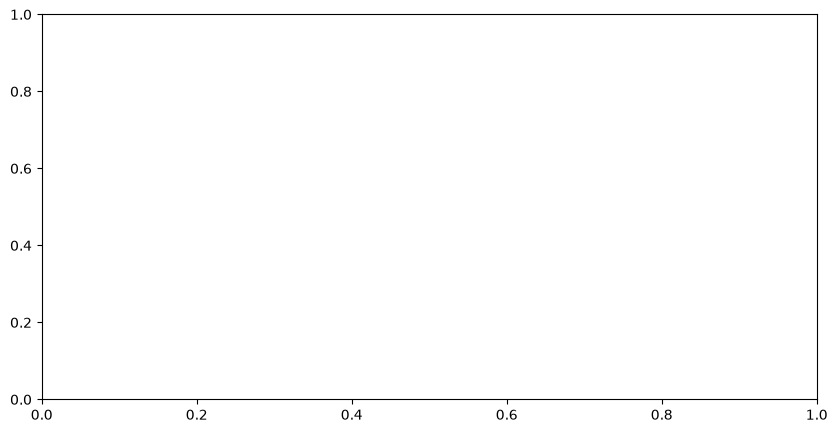

In [33]:
# --- Figure: probe result, collapse vs reverse -------------------------------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
pairs = [f"{a}/{b}\n{lbl}" for a,b,lbl in COLLAPSE]
cx = np.arange(len(COLLAPSE)); w = 0.36
coll = [probe_df[(probe_df.pair==f"{a}/{b}")&(probe_df.direction=="collapse dir")]
        ["pct_flipped_to_partner"].values[0] if
        len(probe_df[(probe_df.pair==f"{a}/{b}")&(probe_df.direction=="collapse dir")]) else 0
        for a,b,_ in COLLAPSE]
rev  = [probe_df[(probe_df.pair==f"{a}/{b}")&(probe_df.direction=="reverse dir")]
        ["pct_flipped_to_partner"].values[0] if
        len(probe_df[(probe_df.pair==f"{a}/{b}")&(probe_df.direction=="reverse dir")]) else 0
        for a,b,_ in COLLAPSE]
ax.bar(cx-w/2, coll, w, label="collapse direction (matches errors)", color="#c0392b", edgecolor="black")
ax.bar(cx+w/2, rev,  w, label="reverse direction", color="#95a5a6", edgecolor="black")
ax.set_xticks(cx); ax.set_xticklabels(pairs, fontsize=9)
ax.set_ylabel("% of correct images that flip to mirror partner\nwhen ONLY position ids are mirrored")
ax.set_title("16a. Position-embedding flip probe: is directional collapse a positional effect?", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
probe_fig = os.path.join(OUTPUT_DIR, "position_flip_probe.png")
plt.savefig(probe_fig, dpi=150, bbox_inches="tight"); plt.show()
print("Saved:", probe_fig)


### 16b. Directional flip-contrastive repair (retraining)

The probe tells us *where* the failure lives. This tests whether we can *fix* it
with a loss that targets the measured direction specifically.

**Standard approach (what we are NOT doing):** add horizontal-flip augmentation.
That is wrong here -- for these classes a flip changes the label, so naive flip
augmentation would teach the model the two classes are the same. That is exactly
the confusion we are trying to remove.

**What we do instead -- an asymmetric flip-contrastive auxiliary loss.** For a
training image whose true class `A` is the *source* of a measured collapse
`A -> B`, we also feed its horizontal flip and require the model to predict `B`
on the flipped image (because a mirrored "keep left" genuinely is "keep right").
This directly teaches the boundary that the collapse erases -- that orientation
is the label-determining feature for these pairs -- and it does so
**asymmetrically**, adding supervision on the side where the model actually
fails rather than uniformly.

The auxiliary term is applied only to the eight mirror-pair classes and weighted
by `LAMBDA_FLIP`; all other classes and the main objective are unchanged.

**Pre-registered prediction (written before the run):**
- Pairs 19/20, 33/34, 38/39 -- collapse is orientation-driven -> auxiliary loss
  should **sharply reduce** collapse-direction errors.
- Pair 36/37 -- partly bidirectional already -> **smaller** improvement.
- Pair 39/38's *brightness*-linked errors (Section 13d, contrast fix recovered
  0/15) are **not** an orientation problem, so this loss should **not** recover
  those specific dark-image failures. If overall accuracy on 38/39 improves but
  the dark-image subset does not, that dissociation is itself a result.
- Overall test accuracy should hold within ~0.5% of the 97.05% baseline
  (this is a targeted fix, not a capacity change; a large drop would signal the
  auxiliary loss is fighting the main objective and LAMBDA_FLIP is too high).

In [ ]:
# --- Directional flip-contrastive training setup ------------------------------
# Map each SOURCE class of a collapse to the TARGET label its flip should get.
# Keras-index space (not raw class ids), since the model outputs Keras indices.
FLIP_TARGET = {}          # keras_idx(source) -> keras_idx(flipped label)
for a, b, _ in COLLAPSE:  # collapse measured as a -> b
    FLIP_TARGET[label_mapping[a]] = label_mapping[b]
    # also supervise the reverse geometric fact (flip of B is A), which is TRUE
    # regardless of error direction and keeps the loss geometrically honest:
    FLIP_TARGET[label_mapping[b]] = label_mapping[a]
FLIP_SOURCE_IDXS = tf.constant(sorted(FLIP_TARGET.keys()), dtype=tf.int32)
_src = tf.constant(sorted(FLIP_TARGET.keys()), dtype=tf.int32)
_dst = tf.constant([FLIP_TARGET[int(k)] for k in sorted(FLIP_TARGET.keys())], dtype=tf.int32)

LAMBDA_FLIP = 0.5   # weight on the auxiliary term; tune if accuracy drifts

def flip_target_lookup(labels):
    """For each label, return its flipped-label target, or -1 if not a mirror class."""
    labels = tf.cast(labels, tf.int32)
    eq = tf.cast(tf.equal(labels[:, None], _src[None, :]), tf.int32)  # [B, S]
    is_mirror = tf.reduce_max(eq, axis=1) > 0
    idx = tf.argmax(eq, axis=1)
    mapped = tf.gather(_dst, idx)
    return tf.where(is_mirror, mapped, tf.fill(tf.shape(labels), -1)), is_mirror

class DirectionalFlipModel(keras.Model):
    """Wraps the ViT classifier. Adds an auxiliary loss: for mirror-pair images,
    the horizontal flip must be classified as the mirror partner. Only the
    train_step changes; inference is identical to the base model."""
    def __init__(self, base, lambda_flip=0.5, **kw):
        super().__init__(**kw)
        self.base = base
        self.lambda_flip = lambda_flip
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.main_tracker = keras.metrics.Mean(name="main_loss")
        self.aux_tracker  = keras.metrics.Mean(name="flip_loss")
        self.acc_tracker  = keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.scce = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    def call(self, x, training=False):
        return self.base(x, training=training)

    def train_step(self, data):
        x, y = data
        y = tf.cast(tf.reshape(y, [-1]), tf.int32)
        flip_labels, is_mirror = flip_target_lookup(y)
        x_flip = tf.image.flip_left_right(x)

        with tf.GradientTape() as tape:
            logits = self.base(x, training=True)
            main = self.scce(y, logits)

            # auxiliary term only over mirror-pair rows
            m = tf.cast(is_mirror, tf.float32)
            denom = tf.reduce_sum(m) + 1e-6
            flip_logits = self.base(x_flip, training=True)
            safe_flip_labels = tf.where(is_mirror, flip_labels, tf.zeros_like(flip_labels))
            per = keras.losses.sparse_categorical_crossentropy(
                safe_flip_labels, flip_logits, from_logits=True)
            aux = tf.reduce_sum(per * m) / denom
            loss = main + self.lambda_flip * aux

        grads = tape.gradient(loss, self.base.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base.trainable_variables))
        self.loss_tracker.update_state(loss)
        self.main_tracker.update_state(main)
        self.aux_tracker.update_state(aux)
        self.acc_tracker.update_state(y, logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        y = tf.cast(tf.reshape(y, [-1]), tf.int32)
        logits = self.base(x, training=False)
        self.acc_tracker.update_state(y, logits)
        self.loss_tracker.update_state(self.scce(y, logits))
        return {"loss": self.loss_tracker.result(), "accuracy": self.acc_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.main_tracker, self.aux_tracker, self.acc_tracker]

print(f"Directional flip loss ready. {len(FLIP_TARGET)} mirror-class -> partner "
      f"mappings, lambda={LAMBDA_FLIP}.")
print("Flip-target map (keras idx):", {int(k): int(v) for k,v in FLIP_TARGET.items()})


In [ ]:
# --- Fine-tune with the directional flip loss --------------------------------
# Start from the trained baseline weights (already in `model`) and do a SHORT
# targeted fine-tune -- we are repairing a boundary, not retraining from scratch.
FLIP_FINETUNE_EPOCHS = 6
FLIP_FINETUNE_LR = 1e-5

dir_model = DirectionalFlipModel(model, lambda_flip=LAMBDA_FLIP)
dir_model.compile(optimizer=keras.optimizers.AdamW(learning_rate=FLIP_FINETUNE_LR,
                                                   weight_decay=0.01))

flip_ckpt = os.path.join(OUTPUT_DIR, "vit_directional_flip.weights.h5")
flip_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(flip_ckpt, monitor="val_accuracy",
                                    save_best_only=True, save_weights_only=True, verbose=1),
]

# Note: train_ds is already shuffled+batched (Section 6), so Keras will print a
# harmless 'shuffle ignored' warning -- expected, not an error.
history_flip = dir_model.fit(
    train_ds, validation_data=val_ds,
    epochs=FLIP_FINETUNE_EPOCHS, callbacks=flip_callbacks, verbose=1,
)
print("Directional flip fine-tune complete.")


### 16c. Did it work? Confirmation against the pre-registered prediction

Re-evaluates the repaired model on the official test set, recomputes the
directional mirror-pair error table, and re-runs the 16a positional probe. The
comparison to the baseline is the result -- and because the predictions in 16b
were written down first, this is a genuine test rather than a post-hoc story.

In [ ]:
# --- Re-evaluate repaired model on the official test set ----------------------
logits_after = predict_logits([os.path.join(DATASET_PATH, p) for p in test_df["Path"]])
y_pred_after = logits_after.argmax(1)
acc_after = (y_pred_after == y_true).mean()
pred_after_id = np.array([inverse_mapping[i] for i in y_pred_after])
true_id = test_df["ClassId"].values

BASELINE_ACC = 0.9705
print(f"Baseline test accuracy : {BASELINE_ACC*100:.2f}%")
print(f"Repaired test accuracy : {acc_after*100:.2f}%")
print(f"Delta                  : {(acc_after-BASELINE_ACC)*100:+.2f} pts")
print("(Pre-registered: should hold within ~0.5%.)\n")

def collapse_counts(pred_id):
    out = {}
    for a, b, _ in COLLAPSE:
        ab = int(((true_id==a) & (pred_id==b)).sum())
        ba = int(((true_id==b) & (pred_id==a)).sum())
        out[f"{a}/{b}"] = (ab, ba)
    return out

base_counts = collapse_counts(np.array([inverse_mapping[i] for i in
                pd.read_csv(os.path.join(OUTPUT_DIR,"test_predictions.csv"))
                  .predicted_class_id.map(label_mapping).values])) \
              if False else None
# baseline directly from the saved predictions file (already class-id space):
_bp = pd.read_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"))
def collapse_counts_from_df(df):
    out={}
    for a,b,_ in COLLAPSE:
        ab=int(((df.true_class_id==a)&(df.predicted_class_id==b)).sum())
        ba=int(((df.true_class_id==b)&(df.predicted_class_id==a)).sum())
        out[f"{a}/{b}"]=(ab,ba)
    return out
base_counts = collapse_counts_from_df(_bp)
after_counts = collapse_counts(pred_after_id)

print(f"{'pair':<8}{'collapse-dir errors':>22}{'reverse-dir errors':>20}")
print(f"{'':<8}{'before -> after':>22}{'before -> after':>20}")
tot_b=tot_a=0
for a,b,lbl in COLLAPSE:
    key=f"{a}/{b}"
    (cb,rb),(ca,ra)=base_counts[key],after_counts[key]
    tot_b+=cb; tot_a+=ca
    print(f"{key:<8}{cb:>9} -> {ca:<9}{rb:>10} -> {ra:<9}   {lbl}")
print(f"\nCollapse-direction errors, total: {tot_b} -> {tot_a} "
      f"({100*(tot_a-tot_b)/max(tot_b,1):+.0f}%)")


In [ ]:
# --- Dissociation check: orientation-fixable vs brightness-linked (pair 38/39) -
# Pre-registered: the loss should fix orientation errors but NOT the dark-image
# 39/38 failures that contrast correction couldn't recover (Section 13d).
res_img = pd.read_csv(os.path.join(OUTPUT_DIR, "resolution_per_image.csv"))
# brightness proxy unavailable per-image here; use the 13c/13d brightness_check
# grouping if present, else fall back to reporting overall 38/39 movement.
after_df = pd.DataFrame({
    "true_class_id": true_id, "predicted_class_id": pred_after_id,
    "filename": test_df["Path"].values,
    "correct": true_id == pred_after_id,
})
after_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions_after_flip.csv"), index=False)

for a,b,lbl in COLLAPSE:
    before_recall = _bp[_bp.true_class_id==a].correct.mean()
    after_recall  = after_df[after_df.true_class_id==a].correct.mean()
    print(f"class {a:>2} ({lbl}): recall {before_recall*100:5.1f}% -> {after_recall*100:5.1f}%")
print("\nSaved: test_predictions_after_flip.csv")


In [ ]:
# --- Re-run the positional probe on the repaired model -----------------------
# If the repair worked by making the boundary orientation-aware, the position
# flip should now move predictions LESS in the collapse direction (the model no
# longer over-relies on the positional shortcut) OR more symmetrically.
set_position_ids("orig"); logits_o2 = predict_logits(probe_paths)
set_position_ids("flip"); logits_f2 = predict_logits(probe_paths)
set_position_ids("orig")
po2 = np.array([inverse_mapping[i] for i in logits_o2.argmax(1)])
pf2 = np.array([inverse_mapping[i] for i in logits_f2.argmax(1)])

rows=[]
for a,b,label in COLLAPSE:
    for src,dst,direction in [(a,b,"collapse dir"),(b,a,"reverse dir")]:
        m = probe_true==src; n=int(m.sum())
        if n==0: continue
        flipped = int(((pf2[m]==dst)&(po2[m]==src)).sum())
        rows.append({"pair":f"{a}/{b}","direction":direction,
                     "pct_flipped_to_partner_AFTER":100*flipped/n})
probe_after = pd.DataFrame(rows)
merged = probe_df.merge(probe_after, on=["pair","direction"], how="left")
print("Positional probe, collapse direction — before vs after repair:\n")
sub = merged[merged.direction=="collapse dir"][
    ["pair","pct_flipped_to_partner","pct_flipped_to_partner_AFTER"]]
sub.columns = ["pair","before_%","after_%"]
print(sub.to_string(index=False, float_format=lambda v: f"{v:.1f}"))
merged.to_csv(os.path.join(OUTPUT_DIR, "position_flip_probe_before_after.csv"), index=False)
print("\nSaved: position_flip_probe_before_after.csv")


### 16d. Replication caveat — directionality across training runs

Two independent training runs of the same corrected baseline both reached
~97.05% / 97.06% test accuracy, and in both, mirror-pair confusions accounted
for roughly a third of all remaining errors (34.9% and 32.9%). That part is
stable.

The *directionality* is only partly stable, and this must be reported honestly:

| Pair | Run 1 (a->b / b->a) | Run 2 (a->b / b->a) |
|------|---------------------|---------------------|
| 19/20 | 23 / 0 | 28 / 0 |
| 33/34 | 20 / 0 | 16 / 0 |
| 38/39 | 0 / 32 | 0 / 6 |
| 36/37 | 46 / 9 | 39 / 33 |

19/20 and 33/34 replicate cleanly -- unidirectional with exactly zero reverse
errors in both runs. 38/39 keeps its direction but its magnitude drops sharply
(32 -> 6). 36/37 does **not** replicate: it was 5:1 asymmetric in run 1 and
essentially symmetric (39/33) in run 2.

With only 60-120 test images per class, these counts are small enough that
run-to-run variance is substantial. The defensible claim is therefore narrower
than "mirror-pair confusion is directional": it is that **some** mirror pairs
(19/20, 33/34 consistently) collapse unidirectionally, while others vary across
seeds. Establishing the effect properly needs several seeds and a confidence
interval on the asymmetry, not a single run -- worth stating as a limitation and,
if time allows, running 3-5 seeds of the baseline and reporting the spread.

## 15. Notes

**GPU choice — this one actually bites.** TensorFlow has no working kernels for
Blackwell (sm_120): RTX 5090, RTX PRO 4000/4500/5000/6000 Blackwell, B200. It's
an open TF bug, not a config problem. Pick Ada or Ampere:

| Safe (Ada / Ampere) | VRAM | Broken (Blackwell) |
|---|---|---|
| RTX 4090 | 24 GB | RTX 5090 |
| RTX 4000 Ada | 20 GB | RTX PRO 4000 Blackwell |
| L40S / L40 | 48 GB | RTX PRO 4500 Blackwell |
| L4 | 24 GB | RTX PRO 5000/6000 Blackwell |
| A100 | 40/80 GB | B200 |
| A6000 / A5000 / A40 | 24–48 GB | |
| RTX 3090 | 24 GB | |

On RunPod these mostly sit under **"NVIDIA previous generation"** — that section
is the safe one here, despite the name. The Section 1 smoke test will catch a
bad card in seconds.

**Pod lifecycle.** `Stop` preserves the volume disk; `Terminate` deletes it.
Always Stop, never Terminate, until the results zip is on your own machine.

If a restart offers to *migrate* the pod, that's RunPod telling you someone else
took your original physical GPU while you were stopped. Migration copies your
data to a new machine and is safe, but you get a new pod ID and IP.

**What's already done and won't repeat.** Sections 3–4 (download + PPM→PNG) are
one-time and skip themselves on re-runs, as long as the volume survives. So
future experiments start straight at Section 5.

**If you hit OOM.** Drop `BATCH_SIZE` to 64, restart the kernel, re-run from
Section 2 (the dataset prep will skip itself).

**Possible next experiment.** If you want a second result for the dissertation,
a ViT-Small vs ViT-Base comparison is more interesting than going bigger:
"comparable accuracy at a fraction of the compute" is a stronger finding on a
near-saturated benchmark than "bigger model, no change". Change the preset in
Section 8 and re-run.
